# Pengembangan Sistem Pengenalan Wajah Berbasis Vision Transformer dan One-Shot Learning yang Robust untuk Deployment pada Edge Device
## Tesis Magister — Teknik Elektro, Universitas Jember
**Mahasiswa:** Juris Vassa Ivandro (241920201009)  
**Platform:** Kaggle Notebook — NVIDIA Tesla T4 × 2  
**Dataset:** CASIA-WebFace (subset 400 ID) — Evaluasi: LFW-style protocol  

---

## Peta Blok Eksperimen

| Blok | Nama Blok | Skenario Tesis | Output |
|------|-----------|---------------|--------|
| **BLOK 0** | Verifikasi Lingkungan & Dependensi | — | GPU/library terverifikasi |
| **BLOK 1** | Instalasi Dependensi | — | timm, foolbox, onnxruntime |
| **BLOK 2** | Akuisisi Dataset CASIA-WebFace | — | Dataset siap diakses |
| **BLOK 3** | Konfigurasi Global & Hyperparameter | — | CFG dict terpusat |
| **BLOK 4** | Konversi Dataset (.rec → .jpg) | — | Folder id_XXXXXX/ |
| **BLOK 5** | Dataset Class, Split Identitas & Augmentasi | — | DataLoader siap |
| **BLOK 6** | Arsitektur Model (ViT + MobileNetV2 + ArcFace) | Bab 3.4 | Model instances |
| **BLOK 7** | Training Loop (ArcFace + Cosine LR + Early Stop) | Bab 3.5 | Fungsi train_model() |
| **BLOK 8** | Bangun Verification Pairs & Fungsi Evaluasi | Bab 3.5 | evaluate_pairs() |
| **BLOK 9** | Eksekusi Training: ViT-Tiny | Skenario 1 | tiny_best.pth |
| **BLOK 10** | Eksekusi Training: ViT-Small | Skenario 1 | small_best.pth |
| **BLOK 11** | Eksekusi Training: MobileNetV2 (Baseline CNN) | Skenario 1 | mob_best.pth |
| **BLOK 12** | Evaluasi Skenario 1 — Akurasi Verifikasi (Clean) | Skenario 1 | AUC, EER, TAR@FAR |
| **BLOK 13** | Evaluasi Skenario 2 — Robustness terhadap Perturbasi | Skenario 2 | Robustness matrix |
| **BLOK 14** | Ablasi Skenario 3 — Pengaruh Ukuran Subset | Skenario 3 | Delta AUC vs n_ID |
| **BLOK 15** | Visualisasi Komprehensif (Kurva, ROC, Heatmap, t-SNE) | Bab 4 | Figure PNG |
| **BLOK 16** | Export ONNX & Validasi Numerik (Edge-Readiness) | Bab 3.7 | .onnx + calib JSON |

> **Output utama fase training:** model `.onnx` + `calibration.json` per backbone,  
> siap dibawa ke fase deployment Jetson Nano 4GB (Skenario 4–5).


## BLOK 0 — Verifikasi Lingkungan & Dependensi

In [1]:
# BLOK 0: Verifikasi GPU, CUDA, dan versi library utama
import subprocess, sys, platform
print("=" * 60)
print("  BLOK 0 — Verifikasi Lingkungan")
print("=" * 60)
print(f"  Python   : {sys.version.split()[0]}")
print(f"  Platform : {platform.platform()}")
!nvidia-smi

  BLOK 0 — Verifikasi Lingkungan
  Python   : 3.12.13
  Platform : Linux-6.6.122+-x86_64-with-glibc2.35
Mon Jun 15 10:02:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                   

## BLOK 1 — Instalasi Dependensi

In [2]:
# BLOK 1: Instalasi library yang tidak tersedia secara default di Kaggle
# Catatan: numpy tidak diupgrade (pakai versi Kaggle bawaan untuk kompatibilitas)
import subprocess, sys

def pip_install(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *args, '-q'])

# pip_install('--upgrade', 'scikit-learn')
# pip_install('--upgrade', 'scipy')
pip_install('timm==1.0.9')           # ViT backbone (vit_tiny/small_patch16_224)
# pip_install('onnx==1.16.0')          # ONNX export
pip_install('onnxruntime')   # Validasi ONNX (CPU) sebelum ke TensorRT
pip_install('foolbox==3.3.3')        # Opsional: adversarial robustness test

print('\n✅ Semua dependensi berhasil diinstall')
print('   Verifikasi versi kunci:')
import timm, onnx, onnxruntime
print(f'   timm          : {timm.__version__}')
print(f'   onnx          : {onnx.__version__}')
print(f'   onnxruntime   : {onnxruntime.__version__}')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 109.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 23.3 MB/s eta 0:00:00

✅ Semua dependensi berhasil diinstall
   Verifikasi versi kunci:
   timm          : 1.0.9
   onnx          : 1.21.0
   onnxruntime   : 1.26.0


## BLOK 2 — Akuisisi Dataset CASIA-WebFace

In [3]:
# BLOK 2: Download CASIA-WebFace dari Kaggle Hub
import kagglehub

print("=" * 60)
print("  BLOK 2 — Akuisisi Dataset CASIA-WebFace")
print("=" * 60)

path = kagglehub.dataset_download("debarghamitraroy/casia-webface")
print(f"\n  Path dataset : {path}")
print("  Format       : MXNet RecordIO (.rec + .idx)")
print("  Akan dikonversi ke JPEG folder structure di BLOK 4")

  BLOK 2 — Akuisisi Dataset CASIA-WebFace

  Path dataset : /kaggle/input/datasets/debarghamitraroy/casia-webface
  Format       : MXNet RecordIO (.rec + .idx)
  Akan dikonversi ke JPEG folder structure di BLOK 4


## BLOK 3 — Konfigurasi Global & Hyperparameter

Semua hyperparameter penelitian dipusatkan di satu dict `CFG` untuk reproduktibilitas.  
Nilai yang tertera merupakan nilai **aktual implementasi** (setelah rekonsiliasi dengan Bab 3):

- `ARCFACE_SCALE=30`, `ARCFACE_MARGIN=0.35` (bukan s=64/m=0.5 versi paper asli — disesuaikan untuk subset kecil)
- `LR=1e-4` single LR untuk semua backbone (konsistensi eksperimen antar backbone)
- `IMG_SIZE=224` → menghasilkan 196 patch + 1 CLS = 197 token per gambar ViT
- `NUM_EPOCHS=15` (disesuaikan constraint T4 Kaggle, bukan 50 epoch seperti awal rencana)

In [4]:
# BLOK 3: Import & Konfigurasi Global
# PERUBAHAN KRITIS:
#   - USE_DP = False  → NONAKTIFKAN DataParallel
#     DataParallel dengan batch kecil justru LEBIH LAMBAT karena overhead scatter/gather
#     Lebih baik pakai satu GPU penuh daripada dua GPU dengan overhead DP
#   - BATCH_SIZE = 64  → Naik dari 16, GPU utilization jauh lebih tinggi  
#   - NUM_WORKERS = 0  → Eliminasi multiprocess spawn issue di Kaggle
#   - DEVICE = cuda:0  → Pin ke GPU 0 secara eksplisit

import os, random, time, warnings, math, json, gc
from pathlib import Path
from collections import defaultdict
warnings.filterwarnings('ignore')

import numpy as np
import cv2
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler
import torchvision.transforms as T
import timm
import psutil

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score,
)
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# ── DEVICE ────────────────────────────────────────────────────────────────
if not torch.cuda.is_available():
    raise RuntimeError("GPU tidak tersedia! Aktifkan di Settings → Accelerator → GPU T4 x2")

DEVICE = torch.device('cuda:0')
N_GPU  = torch.cuda.device_count()
USE_DP = False

print("=" * 60)
print("  BLOK 3 — Device & Config")
print("=" * 60)
print(f"  PyTorch : {torch.__version__}")
print(f"  DEVICE  : {DEVICE}  (n_gpu={N_GPU})")
print(f"  USE_DP  : {USE_DP}")

# ── AUTOCAST COMPATIBILITY ─────────────────────────────────────────────────
# PyTorch >= 2.0 : torch.amp.autocast(device_type='cuda')
# PyTorch <  2.0 : torch.cuda.amp.autocast()
# Wrapper ini otomatis pilih yang benar berdasarkan versi

_pt_version = tuple(int(x) for x in torch.__version__.split('.')[:2])

if _pt_version >= (2, 0):
    import torch.amp as _torch_amp
    def make_autocast(enabled=True):
        return _torch_amp.autocast(device_type='cuda', enabled=enabled)
    print(f"  autocast : torch.amp.autocast (PyTorch >= 2.0) ✓")
else:
    from torch.cuda.amp import autocast as _autocast_legacy
    def make_autocast(enabled=True):
        return _autocast_legacy(enabled=enabled)
    print(f"  autocast : torch.cuda.amp.autocast (PyTorch < 2.0) ✓")

# Test autocast bisa berjalan
_test = torch.randn(4, 3, 32, 32, device=DEVICE)
_conv = torch.nn.Conv2d(3, 8, 3, padding=1).to(DEVICE)
with make_autocast():
    _out = _conv(_test)
print(f"  autocast test: {tuple(_out.shape)} dtype={_out.dtype} ✓")
del _test, _conv, _out
torch.cuda.empty_cache()

# ── CONFIG ─────────────────────────────────────────────────────────────────
CFG = dict(
    SEED             = 42,

    # Dataset
    TOTAL_IDENTITIES = 500,
    MIN_PER_ID       = 15,
    MAX_PER_ID       = 30,

    # Split
    TRAIN_ID_RATIO   = 0.70,
    VAL_ID_RATIO     = 0.15,
    TEST_ID_RATIO    = 0.15,

    # Input
    IMG_SIZE         = 224,
    EMBEDDING_DIM    = 512,

    # Training
    BATCH_SIZE       = 64,
    NUM_EPOCHS       = 15,
    NUM_WORKERS      = 0,
    LR               = 1e-4,
    LR_CNN           = 5e-4,
    WEIGHT_DECAY     = 0.01,
    WARMUP_RATIO     = 0.20,
    WARMUP_RATIO_CNN = 0.10,
    EARLY_STOP_PAT   = 5,

    # ArcFace (Bab 3.4)
    ARCFACE_SCALE    = 30,
    ARCFACE_MARGIN   = 0.35,

    # Verification pairs
    N_PAIRS_VAL      = 1500,
    N_PAIRS_TEST     = 6000,

    # Backbones
    BACKBONES = {
        'vit_tiny'    : 'vit_tiny_patch16_224',
        'vit_small'   : 'vit_small_patch16_224',
        'mobilenet_v2': 'mobilenetv2_100',
    },

    # Path
    REC_PATH   = '/kaggle/input/datasets/debarghamitraroy/casia-webface/casia-webface/train.rec',
    IDX_PATH   = '/kaggle/input/datasets/debarghamitraroy/casia-webface/casia-webface/train.idx',
    JPG_DIR    = Path('/kaggle/working/casia_500id'),
    OUTPUT_DIR = Path('/kaggle/working/outputs'),
)

CFG['OUTPUT_DIR'].mkdir(parents=True, exist_ok=True)
CFG['JPG_DIR'].mkdir(parents=True, exist_ok=True)

random.seed(CFG['SEED'])
np.random.seed(CFG['SEED'])
torch.manual_seed(CFG['SEED'])
torch.cuda.manual_seed_all(CFG['SEED'])
torch.backends.cudnn.benchmark     = True
torch.backends.cudnn.deterministic = False

print(f"\n  CFG aktif:")
print(f"  BATCH_SIZE  = {CFG['BATCH_SIZE']}")
print(f"  NUM_WORKERS = {CFG['NUM_WORKERS']}")
print(f"  N_PAIRS_VAL = {CFG['N_PAIRS_VAL']}")
print(f"  N_PAIRS_TEST= {CFG['N_PAIRS_TEST']}")
print(f"  BLOK 3 selesai ✓")


# ── SHARED VISUALIZATION HELPERS (dipanggil di BLOK 9-14) ─────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Image as IPImage

try:
    matplotlib.use('module://matplotlib_inline.backend_inline')
except:
    pass

PLT_STYLE = {
    'figure.facecolor' : '#0d1117', 'axes.facecolor'  : '#161b22',
    'axes.edgecolor'   : '#30363d', 'axes.labelcolor'  : '#e6edf3',
    'text.color'       : '#e6edf3', 'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e', 'grid.color'       : '#21262d',
    'grid.linestyle'   : '--',      'grid.alpha'       :  0.6,
    'font.family'      : 'monospace','legend.facecolor' : '#21262d',
    'legend.edgecolor' : '#30363d',
}
plt.rcParams.update(PLT_STYLE)

CLR = {
    'tiny'  : '#79c0ff', 'small': '#f78166',
    'mob'   : '#56d364', 'accent': '#d2a8ff',
}

def save_show(fig, filename, title=''):
    """Simpan figure ke disk DAN tampilkan inline di notebook."""
    path = CFG['OUTPUT_DIR'] / filename
    fig.savefig(str(path), dpi=120, bbox_inches='tight', facecolor='#0d1117')
    plt.close(fig)
    if title:
        print(f'  ── {title}')
    display(IPImage(str(path)))
    print(f'  {filename} saved ✓')

print("  Visualization helpers loaded ✓")

  BLOK 3 — Device & Config
  PyTorch : 2.10.0+cu128
  DEVICE  : cuda:0  (n_gpu=2)
  USE_DP  : False
  autocast : torch.amp.autocast (PyTorch >= 2.0) ✓
  autocast test: (4, 8, 32, 32) dtype=torch.float16 ✓

  CFG aktif:
  BATCH_SIZE  = 64
  NUM_WORKERS = 0
  N_PAIRS_VAL = 1500
  N_PAIRS_TEST= 6000
  BLOK 3 selesai ✓
  Visualization helpers loaded ✓


## BLOK 4 — Konversi Dataset: RecordIO → Folder JPEG

CASIA-WebFace tersedia dalam format MXNet RecordIO (`.rec` + `.idx`).  
Blok ini mengkonversi ke struktur folder `id_XXXXXX/img_XXX.jpg` yang standar,  
sekaligus melakukan **stratified sampling** (400 ID, min 15 gambar/ID, max 30 gambar/ID).

In [5]:
# BLOK 4: Konversi MXNet RecordIO → folder JPEG (stratified sampling)

import struct
import shutil

def read_idx_file(idx_path):
    """Baca file .idx: key<TAB>offset per baris."""
    entries = []
    with open(idx_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 2:
                try:
                    entries.append((int(parts[0]), int(parts[1])))
                except ValueError:
                    pass
    return entries

def read_record_at(f, offset):
    """
    CASIA RecordIO header (32 bytes):
      [0:4]  magic=0xced7230a, [4:8] length, [12:16] label(float32), [32:] JPEG data
    """
    MAGIC, HSIZE = 0xced7230a, 32
    try:
        f.seek(offset)
        hdr = f.read(HSIZE)
        if len(hdr) < HSIZE:
            return None, None
        if struct.unpack_from('<I', hdr, 0)[0] != MAGIC:
            return None, None
        length = struct.unpack_from('<I', hdr, 4)[0]
        label  = struct.unpack_from('<f', hdr, 12)[0]
        data   = f.read(length - (HSIZE - 8))
        return int(label), data
    except Exception:
        return None, None

def convert_casia(rec_path, idx_path, out_dir, cfg):
    """
    3-pass konversi:
      Pass 1 — index semua offset per identitas
      Pass 2 — filter (>= MIN_PER_ID) dan stratified sample TOTAL_IDENTITIES
      Pass 3 — decode JPEG & tulis ke disk (cap MAX_PER_ID per ID)
    """
    out_dir = Path(out_dir)
    
    # [PERUBAHAN]: Memaksa reset direktori untuk mengatasi caching Kaggle
    if out_dir.exists():
        print("  Membersihkan direktori lama...")
        shutil.rmtree(out_dir)
        
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f'  Membaca index: {idx_path}')
    entries = read_idx_file(idx_path)
    print(f'  Total record  : {len(entries):,}')

    # Pass 1
    id_to_offsets = defaultdict(list)
    with open(rec_path, 'rb') as f:
        for key, off in tqdm(entries, desc='  Pass1 indexing'):
            lbl, _ = read_record_at(f, off)
            if lbl is not None:
                id_to_offsets[lbl].append(off)

    # Pass 2
    valid_ids   = [i for i, o in id_to_offsets.items() if len(o) >= cfg['MIN_PER_ID']]
    rng         = random.Random(cfg['SEED'])
    sampled_ids = rng.sample(valid_ids, min(cfg['TOTAL_IDENTITIES'], len(valid_ids)))
    sampled_ids.sort()
    print(f'  Total identitas valid : {len(valid_ids):,}')
    print(f'  Sampled (seed={cfg["SEED"]}): {len(sampled_ids)} ID')

    # Pass 3
    total_written = 0
    with open(rec_path, 'rb') as f:
        for lbl in tqdm(sampled_ids, desc='  Pass3 writing'):
            folder = out_dir / f'id_{lbl:06d}'
            folder.mkdir(exist_ok=True)
            for i, off in enumerate(id_to_offsets[lbl][:cfg['MAX_PER_ID']]):
                _, data = read_record_at(f, off)
                if data is None:
                    continue
                img = cv2.imdecode(np.frombuffer(data, np.uint8), cv2.IMREAD_COLOR)
                if img is None:
                    continue
                img_r = cv2.resize(img, (cfg['IMG_SIZE'], cfg['IMG_SIZE']))
                cv2.imwrite(str(folder / f'img_{i:03d}.jpg'), img_r,
                            [cv2.IMWRITE_JPEG_QUALITY, 95])
                total_written += 1

    print(f'\n  Konversi selesai')
    print(f'  Total gambar  : {total_written:,}')
    print(f'  Total folder  : {len(sampled_ids)}')
    return out_dir


print("=" * 60)
print("  BLOK 4 — Konversi Dataset RecordIO → JPEG")
print("=" * 60)

if Path(CFG['REC_PATH']).exists():
    convert_casia(CFG['REC_PATH'], CFG['IDX_PATH'], CFG['JPG_DIR'], CFG)
else:
    print(f'  File .rec tidak ditemukan — mohon periksa dataset!')

# Sanity check
all_folders = sorted(CFG['JPG_DIR'].glob('id_*'))
img_counts  = [len(list(f.glob('*.jpg'))) for f in all_folders]
print(f'\n  Verifikasi dataset:')
print(f'  Jumlah identitas : {len(all_folders)}')
if img_counts:
    print(f'  Gambar/ID        : min={min(img_counts)}, max={max(img_counts)}, mean={np.mean(img_counts):.1f}')
    print(f'  Total gambar     : {sum(img_counts):,}')

  BLOK 4 — Konversi Dataset RecordIO → JPEG
  Membersihkan direktori lama...
  Membaca index: /kaggle/input/datasets/debarghamitraroy/casia-webface/casia-webface/train.idx
  Total record  : 501,196


  Pass1 indexing:   0%|          | 0/501196 [00:00<?, ?it/s]

  Total identitas valid : 9,913
  Sampled (seed=42): 500 ID


  Pass3 writing:   0%|          | 0/500 [00:00<?, ?it/s]


  Konversi selesai
  Total gambar  : 12,517
  Total folder  : 500

  Verifikasi dataset:
  Jumlah identitas : 500
  Gambar/ID        : min=15, max=30, mean=25.0
  Total gambar     : 12,517


## BLOK 5 — Dataset Class, Split Identitas & Augmentasi

**Prinsip utama:** Split dilakukan **per identitas** (bukan per gambar) untuk menjaga  
validitas protokol one-shot: identitas di val/test tidak pernah muncul saat training.  
Augmentasi train bersifat konservatif sesuai Bab 3.3.

In [6]:
# BLOK 5: Dataset class, disjoint identity split, transforms
# FIX MEMORY LEAK: Gunakan FaceDataset (on-disk) bukan CachedFaceDataset.
# CachedFaceDataset menyimpan ~1.3 GB numpy list di RAM yang sulit di-gc.
# FaceDataset membaca per-gambar saat __getitem__ — Kaggle SSD cukup cepat.

import gc, psutil, time

class FaceDataset(Dataset):
    """On-disk face dataset — tidak menyimpan gambar di RAM."""
    def __init__(self, paths, labels, transform=None):
        self.paths     = [Path(p) for p in paths]
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(str(self.paths[idx]))
        if img is None:
            img = np.zeros((CFG['IMG_SIZE'], CFG['IMG_SIZE'], 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


def split_by_identity(jpg_dir, cfg):
    """Split DISJOINT berbasis identitas."""
    all_ids = sorted([d for d in Path(jpg_dir).iterdir() if d.is_dir()])
    rng = random.Random(cfg['SEED'])
    rng.shuffle(all_ids)
    n_total = len(all_ids)
    n_train = int(n_total * cfg['TRAIN_ID_RATIO'])
    n_val   = int(n_total * cfg['VAL_ID_RATIO'])
    train_ids = all_ids[:n_train]
    val_ids   = all_ids[n_train:n_train + n_val]
    test_ids  = all_ids[n_train + n_val:]
    assert len(set(train_ids) & set(val_ids))  == 0, "LEAK: train-val!"
    assert len(set(train_ids) & set(test_ids)) == 0, "LEAK: train-test!"
    assert len(set(val_ids)   & set(test_ids)) == 0, "LEAK: val-test!"
    print(f'  Split disjoint identitas:')
    print(f'    Train : {len(train_ids):3d} ID')
    print(f'    Val   : {len(val_ids):3d} ID  (unseen)')
    print(f'    Test  : {len(test_ids):3d} ID  (unseen)')
    print(f'  Identity leakage check: OK')
    return train_ids, val_ids, test_ids


def build_training_index(train_id_folders):
    """Bangun (paths, int_labels) dengan label 0..N-1."""
    paths, labels = [], []
    id_to_label = {f.name: idx for idx, f in enumerate(train_id_folders)}
    for folder in train_id_folders:
        imgs = sorted(folder.glob('*.jpg'))
        paths.extend(imgs)
        labels.extend([id_to_label[folder.name]] * len(imgs))
    return paths, labels, len(id_to_label)


_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomGrayscale(p=0.1),
    T.RandomApply([T.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5))], p=0.3),
    T.ToTensor(),
    T.Normalize(_MEAN, _STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.10), ratio=(0.3, 3.3), value=0),
])

test_transform = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(_MEAN, _STD),
])

print("=" * 60)
print("  BLOK 5 — Dataset Split & DataLoader")
print("=" * 60)

train_ids, val_ids, test_ids = split_by_identity(CFG['JPG_DIR'], CFG)
train_paths, train_labels, NUM_TRAIN_IDS = build_training_index(train_ids)
print(f'\n  Training set: {len(train_paths):,} gambar | {NUM_TRAIN_IDS} kelas')

train_ds = FaceDataset(train_paths, train_labels, transform=train_transform)
train_loader = DataLoader(
    train_ds,
    batch_size         = CFG['BATCH_SIZE'],
    shuffle            = True,
    num_workers        = 2,
    pin_memory         = True,
    drop_last          = True,
    persistent_workers = True,
    prefetch_factor    = 2,
)

ram = psutil.virtual_memory()
print(f'  RAM: {ram.used/1e9:.1f} / {ram.total/1e9:.1f} GB | Steps/epoch: {len(train_loader)}')
s_img, s_lbl = train_ds[0]
print(f'  Sample: shape={s_img.shape}, label={s_lbl}')
print(f'  FaceDataset on-disk aktif — RAM tidak digunakan untuk cache gambar ✓')

  BLOK 5 — Dataset Split & DataLoader
  Split disjoint identitas:
    Train : 350 ID
    Val   :  75 ID  (unseen)
    Test  :  75 ID  (unseen)
  Identity leakage check: OK

  Training set: 8,771 gambar | 350 kelas
  RAM: 1.6 / 33.7 GB | Steps/epoch: 137
  Sample: shape=torch.Size([3, 224, 224]), label=0
  FaceDataset on-disk aktif — RAM tidak digunakan untuk cache gambar ✓


## BLOK 6 — Arsitektur Model: ViT Embedder + MobileNetV2 Embedder + ArcFace Head

Tiga backbone dibandingkan sesuai Bab 3.4 Tabel 3.4:
- **ViT-Tiny** (~5.7 M params): backbone utama ringan, target Jetson Nano
- **ViT-Small** (~22 M params): backbone utama akurasi lebih tinggi
- **MobileNetV2** (~3.4 M params): baseline CNN untuk komparasi empiris ViT vs CNN

Semua backbone berbagi head yang identik: `Linear(feat_dim → 512) → BatchNorm1d → L2-normalize`.  
Arsitektur ini selaras dengan Gambar 3.2 (fase training) pada laporan tesis.

In [7]:
# BLOK 6: FaceEmbedder + ArcFaceHead
# PERUBAHAN: Tidak ada DataParallel — single GPU lebih stabil dan cukup cepat

class FaceEmbedder(nn.Module):
    """
    Face embedding network.
    Pipeline: Input [B,3,224,224] → backbone → Linear → LayerNorm → L2-normalize → [B,512]
    """
    def __init__(self, backbone_key, embedding_dim=512, pretrained=True):
        super().__init__()
        self.backbone_key = backbone_key
        timm_name = CFG['BACKBONES'][backbone_key]
        is_vit    = 'vit' in backbone_key
        pool      = 'token' if is_vit else 'avg'
        self.backbone = timm.create_model(
            timm_name, pretrained=pretrained, num_classes=0, global_pool=pool,
        )
        feat_dim   = self.backbone.num_features
        self.head  = nn.Sequential(
            nn.Linear(feat_dim, embedding_dim, bias=False),
            nn.LayerNorm(embedding_dim),
        )
        self.embedding_dim = embedding_dim

    def forward(self, x):
        feat = self.backbone(x)
        emb  = self.head(feat)
        return F.normalize(emb, p=2, dim=1)

    def count_params(self):
        return sum(p.numel() for p in self.parameters())


class ArcFaceHead(nn.Module):
    """ArcFace loss — Deng et al. (2019). s=30, m=0.35."""
    def __init__(self, embedding_dim, num_classes, margin=None, scale=None):
        super().__init__()
        self.margin = margin or CFG['ARCFACE_MARGIN']
        self.scale  = scale  or CFG['ARCFACE_SCALE']
        self.weight = nn.Parameter(torch.randn(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        self.cos_m = math.cos(self.margin)
        self.sin_m = math.sin(self.margin)
        self.th    = math.cos(math.pi - self.margin)
        self.mm    = math.sin(math.pi - self.margin) * self.margin

    def forward(self, embeddings, labels):
        W       = F.normalize(self.weight, dim=1)
        cosine  = embeddings @ W.t()
        sine    = torch.sqrt((1 - cosine**2).clamp(1e-7))
        phi     = cosine * self.cos_m - sine * self.sin_m
        phi     = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot = F.one_hot(labels, num_classes=W.size(0)).float()
        logits  = (one_hot * phi + (1 - one_hot) * cosine) * self.scale
        return F.cross_entropy(logits, labels)


def get_core(model):
    """Helper — tidak perlu unwrap DP karena USE_DP=False."""
    return model.module if isinstance(model, nn.DataParallel) else model


print("=" * 60)
print("  BLOK 6 — Arsitektur Model")
print("=" * 60)
print(f"  USE_DP = {USE_DP}  (single GPU mode)")

for bkey, bname in CFG['BACKBONES'].items():
    m = FaceEmbedder(bkey, CFG['EMBEDDING_DIM']).to(DEVICE)
    params = m.count_params()
    # Quick forward test — verifikasi model benar-benar di GPU
    with torch.no_grad():
        x   = torch.randn(2, 3, CFG['IMG_SIZE'], CFG['IMG_SIZE']).to(DEVICE)
        out = m(x)
        on_gpu = next(m.parameters()).device.type == 'cuda'
    print(f"  {bkey:<16}: {params/1e6:.1f}M params | out={tuple(out.shape)} | GPU={on_gpu} ✓")
    del m, x, out
    gc.collect()
    torch.cuda.empty_cache()

print(f"\n  Semua model verified di GPU ✓")

  BLOK 6 — Arsitektur Model
  USE_DP = False  (single GPU mode)


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

  vit_tiny        : 5.6M params | out=(2, 512) | GPU=True ✓


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

  vit_small       : 21.9M params | out=(2, 512) | GPU=True ✓


model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

  mobilenet_v2    : 2.9M params | out=(2, 512) | GPU=True ✓

  Semua model verified di GPU ✓


## BLOK 7 — Training Loop & Fungsi Evaluasi

Training loop menggunakan:
- **Optimizer:** AdamW dengan cosine annealing + linear warmup
- **Loss:** ArcFace (metric learning, Deng et al. 2019)
- **Mixed precision:** FP16 via GradScaler untuk efisiensi T4
- **Early stopping:** patience=5 epoch tanpa improvement val AUC
- **Checkpoint:** disimpan hanya pada epoch dengan val AUC terbaik

`evaluate_pairs()` menghitung metrik biometrik standar:  
AUC, EER, Accuracy, Precision, Recall, F1, **TAR@FAR=1%**, **TAR@FAR=0.1%**

In [8]:
# BLOK 7A: Fungsi membangun verification pairs & evaluasi biometrik
# FIX MEMORY LEAK:
#   1. full_arrays=False by default → hanya return scalars saat per-epoch validation
#   2. Tensor ta/tb di-del eksplisit per batch
#   3. batch_size default 128 (lebih efisien di T4)

def build_verification_pairs(identities, n_pairs, seed=42):
    """Bangun pasangan (path_a, path_b, label) untuk evaluasi verifikasi."""
    rng = random.Random(seed)
    id_to_imgs = {
        idd: sorted(idd.glob('*.jpg'))
        for idd in identities
        if len(list(idd.glob('*.jpg'))) >= 2
    }
    valid_ids = list(id_to_imgs.keys())
    if len(valid_ids) < 2:
        raise ValueError('Butuh minimal 2 identitas dengan >=2 gambar')
    pairs, labels = [], []
    n_half = n_pairs // 2
    for _ in range(n_half):
        idd = rng.choice(valid_ids)
        a, b = rng.sample(id_to_imgs[idd], 2)
        pairs.append((a, b)); labels.append(1)
    for _ in range(n_half):
        id_a, id_b = rng.sample(valid_ids, 2)
        a = rng.choice(id_to_imgs[id_a])
        b = rng.choice(id_to_imgs[id_b])
        pairs.append((a, b)); labels.append(0)
    return pairs, labels


@torch.no_grad()
def evaluate_pairs(model, pairs, labels, transform=None,
                   batch_size=128, perturb_fn=None, full_arrays=False):
    """
    Evaluasi verifikasi wajah berbasis cosine similarity.

    FIX: full_arrays=False (default) → hanya return scalars.
         Aktifkan full_arrays=True HANYA untuk evaluasi final (bukan per-epoch val).
    FIX: Del tensor ta/tb/ea/eb eksplisit setiap batch.
    FIX: batch_size=128 (lebih sedikit CUDA launch overhead vs 64).
    """
    if transform is None:
        transform = test_transform
    model.eval()
    sims_list = []

    for i in range(0, len(pairs), batch_size):
        batch = pairs[i:i + batch_size]
        imgs_a, imgs_b = [], []
        for a_path, b_path in batch:
            ia = cv2.cvtColor(cv2.imread(str(a_path)), cv2.COLOR_BGR2RGB)
            ib = cv2.cvtColor(cv2.imread(str(b_path)), cv2.COLOR_BGR2RGB)
            if perturb_fn is not None:
                ia = perturb_fn(ia)
            imgs_a.append(transform(ia))
            imgs_b.append(transform(ib))

        ta = torch.stack(imgs_a).to(DEVICE, non_blocking=True)
        tb = torch.stack(imgs_b).to(DEVICE, non_blocking=True)
        # with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
        with make_autocast(enabled=True):
            ea = model(ta)
            eb = model(tb)
        sim = F.cosine_similarity(ea, eb, dim=1).cpu().numpy()
        sims_list.extend(sim.tolist())
        del ta, tb, ea, eb, sim  # FIX: eksplisit del per batch

    sims       = np.array(sims_list, dtype=np.float32)
    labels_arr = np.array(labels,    dtype=np.int32)
    del sims_list

    auc           = float(roc_auc_score(labels_arr, sims))
    fpr, tpr, thr = roc_curve(labels_arr, sims)
    fnr           = 1 - tpr
    eer_idx       = int(np.nanargmin(np.abs(fpr - fnr)))
    eer           = float((fpr[eer_idx] + fnr[eer_idx]) / 2)
    threshold     = float(thr[eer_idx])
    preds         = (sims >= threshold).astype(np.int32)
    acc           = float((preds == labels_arr).mean())
    prec          = float(precision_score(labels_arr, preds, zero_division=0))
    rec           = float(recall_score(labels_arr,  preds, zero_division=0))
    f1            = float(f1_score(labels_arr,      preds, zero_division=0))

    def tar_at_far(target_far):
        idx = max(0, min(int(np.searchsorted(fpr, target_far, side='right')) - 1, len(tpr) - 1))
        return float(tpr[idx])

    result = dict(
        auc=auc, eer=eer, threshold=threshold,
        accuracy=acc, precision=prec, recall=rec, f1=f1,
        tar_far_1pct=tar_at_far(0.01),
        tar_far_01pct=tar_at_far(0.001),
    )
    if full_arrays:
        result['similarities'] = sims
        result['labels']       = labels_arr
        result['fpr']          = fpr.astype(np.float32)
        result['tpr']          = tpr.astype(np.float32)
    else:
        del sims, labels_arr, fpr, tpr, thr, preds

    return result


def serialize_pairs(pairs, labels, path):
    """Simpan pairs ke JSON untuk reproducibility."""
    data = [{'a': str(a), 'b': str(b), 'label': int(l)}
            for (a, b), l in zip(pairs, labels)]
    with open(path, 'w') as f:
        json.dump(data, f)


print("  BLOK 7A — build_verification_pairs() & evaluate_pairs() terdefinisi")
print("  FIX: full_arrays=False default | batch_size=128 | del tensor per batch")


  BLOK 7A — build_verification_pairs() & evaluate_pairs() terdefinisi
  FIX: full_arrays=False default | batch_size=128 | del tensor per batch


In [9]:
# BLOK 7B: train_model — loop utama
# PERUBAHAN KRITIS:
#   - set_to_none=True di zero_grad (lebih hemat memory)
#   - del imgs, lbls, emb, loss per step (cegah akumulasi)
#   - del arcface, optimizer, scheduler, scaler setelah selesai
#   - return history + best_path

def train_model(model, name, train_loader, val_pairs, val_labels, cfg,
                lr=None, warmup_ratio=None, num_train_ids=None):

    lr  = lr  or cfg['LR']
    wr  = warmup_ratio or cfg['WARMUP_RATIO']
    n_ids = num_train_ids or NUM_TRAIN_IDS

    # Pastikan model di GPU yang benar sebelum mulai
    model = model.to(DEVICE)
    model.train()

    # Verifikasi GPU
    _param_device = next(model.parameters()).device
    assert _param_device.type == 'cuda', \
        f"MODEL DI {_param_device}, BUKAN CUDA! Cek DEVICE setup."
    print(f"  Model verified di {_param_device} ✓")

    arcface   = ArcFaceHead(cfg['EMBEDDING_DIM'], n_ids).to(DEVICE)
    optimizer = optim.AdamW(
        list(model.parameters()) + list(arcface.parameters()),
        lr=lr, weight_decay=cfg['WEIGHT_DECAY'],
    )

    total_steps  = len(train_loader) * cfg['NUM_EPOCHS']
    warmup_steps = int(total_steps * wr)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    scaler    = GradScaler(enabled=True)

    history   = {'train_loss':[], 'val_auc':[], 'val_eer':[], 'val_acc':[], 'lr':[]}
    best_auc  = 0.0
    patience  = 0
    best_path = cfg['OUTPUT_DIR'] / f'{name}_best.pth'

    print(f'\n{"=" * 65}')
    print(f'  Training: {name} | LR={lr} | warmup={wr*100:.0f}% | epochs={cfg["NUM_EPOCHS"]}')
    print(f'  Batch={cfg["BATCH_SIZE"]} | Steps/epoch={len(train_loader)} | n_ids={n_ids}')
    print(f'{"=" * 65}')

    for epoch in range(cfg['NUM_EPOCHS']):
        model.train(); arcface.train()
        run_loss, n_seen = 0.0, 0
        t0 = time.time()

        pbar = tqdm(train_loader, desc=f'  Ep {epoch+1:02d}/{cfg["NUM_EPOCHS"]}', leave=False)
        for imgs, lbls in pbar:
            # Pindahkan ke GPU — ini wajib ada dan benar
            imgs = imgs.to(DEVICE, non_blocking=True)
            lbls = lbls.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with make_autocast(enabled=True):
                emb  = model(imgs)
                loss = arcface(emb, lbls)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                list(model.parameters()) + list(arcface.parameters()), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            run_loss += loss.item() * lbls.size(0)
            n_seen   += lbls.size(0)
            pbar.set_postfix(loss=f'{loss.item():.3f}',
                             gpu=f'{torch.cuda.memory_allocated()/1e9:.1f}GB')
            del imgs, lbls, emb, loss

        train_loss = run_loss / n_seen

        # Validation — scalars only
        val_res = evaluate_pairs(model, val_pairs, val_labels, full_arrays=False)

        history['train_loss'].append(train_loss)
        history['val_auc'].append(val_res['auc'])
        history['val_eer'].append(val_res['eer'])
        history['val_acc'].append(val_res['accuracy'])
        history['lr'].append(scheduler.get_last_lr()[0])

        is_best = val_res['auc'] > best_auc
        if is_best:
            best_auc = val_res['auc']; patience = 0; marker = 'BEST'
            torch.save({
                'model_state_dict': model.state_dict(),
                # 'backbone_key'    : model.backbone_key,
                'backbone_key': get_core(model).backbone_key,
                'epoch'           : epoch,
                'val_auc'         : best_auc,
                'val_eer'         : val_res['eer'],
                'val_threshold'   : val_res['threshold'],
                'cfg_snapshot'    : {k: str(v) if isinstance(v, Path) else v
                                     for k, v in cfg.items() if k != 'BACKBONES'},
            }, best_path)
        else:
            patience += 1
            marker    = f'pat {patience}/{cfg["EARLY_STOP_PAT"]}'

        elapsed = time.time() - t0
        vram = torch.cuda.memory_allocated() / 1e9
        print(f'  [{marker:^10}] ep={epoch+1:02d} | loss={train_loss:.4f} | '
              f'AUC={val_res["auc"]:.4f} | EER={val_res["eer"]:.4f} | '
              f'TAR@1%={val_res["tar_far_1pct"]:.4f} | {elapsed:.0f}s | VRAM={vram:.1f}GB')
        del val_res

        if patience >= cfg['EARLY_STOP_PAT']:
            print(f'  Early stop di epoch {epoch+1}')
            break

    print(f'\n  Selesai. Best val AUC: {best_auc:.4f} → {best_path.name}')

    # Bersihkan semua objek training dari GPU
    del arcface, optimizer, scheduler, scaler
    gc.collect()
    torch.cuda.empty_cache()

    vram_after = torch.cuda.memory_allocated() / 1e9
    print(f'  VRAM setelah cleanup: {vram_after:.3f} GB')

    return history, best_path


def load_best_model(ckpt_path):
    ckpt  = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model = FaceEmbedder(ckpt['backbone_key'], CFG['EMBEDDING_DIM'], pretrained=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model = model.to(DEVICE)
    model.eval()
    return model, ckpt


print("  BLOK 7B — train_model() & load_best_model() OK")

  BLOK 7B — train_model() & load_best_model() OK


## BLOK 8 — Verification pairs (val & test)
Pairs dibangun sekali dan disimpan sebagai list path → tidak menyimpan gambar di RAM

In [10]:
print("=" * 60)
print("  BLOK 8 — Bangun Verification Pairs")
print("=" * 60)

val_pairs,  val_labels  = build_verification_pairs(val_ids,  CFG['N_PAIRS_VAL'],  seed=CFG['SEED'])
test_pairs, test_labels = build_verification_pairs(test_ids, CFG['N_PAIRS_TEST'], seed=CFG['SEED'] + 1)

print(f'  Val  pairs  : {len(val_pairs):,}  (genuine={sum(val_labels):,})')
print(f'  Test pairs  : {len(test_pairs):,}  (genuine={sum(test_labels):,})')

# Simpan untuk reproducibility
serialize_pairs(val_pairs,  val_labels,  CFG['OUTPUT_DIR'] / 'val_pairs.json')
serialize_pairs(test_pairs, test_labels, CFG['OUTPUT_DIR'] / 'test_pairs.json')
print(f'  Pairs tersimpan: val_pairs.json, test_pairs.json')

  BLOK 8 — Bangun Verification Pairs
  Val  pairs  : 1,500  (genuine=750)
  Test pairs  : 6,000  (genuine=3,000)
  Pairs tersimpan: val_pairs.json, test_pairs.json


### PRE-TRAINING SPEED TEST

In [11]:
# ═══════════════════════════════════════════════════════
# SPEED TEST — Jalankan SEBELUM BLOK 9 training dimulai
# FIX 1: Hapus 'from torch.cuda.amp import autocast' — pakai make_autocast()
# FIX 2: Hapus USE_DP / DataParallel — USE_DP=False permanen
# FIX 3: del imgs, lbls per batch di DataLoader test
# FIX 4: del 'out' di dalam loop benchmark — cegah akumulasi 20 tensor
# ═══════════════════════════════════════════════════════
import time, gc
import torch

print("=" * 60)
print("  PRE-TRAINING SPEED TEST")
print("=" * 60)
print(f"  PyTorch : {torch.__version__}")
print(f"  DEVICE  : {DEVICE}")
print(f"  USE_DP  : {USE_DP}")

# ── Test 1: GPU compute speed ─────────────────────────────────────────────
print("\n  [Test 1] GPU forward pass speed...")

test_model = FaceEmbedder('vit_tiny', 512).to(DEVICE)
# FIX 2: Tidak ada DataParallel — USE_DP=False permanen
# Baris 'if USE_DP: DataParallel' dihapus
test_model.eval()

dummy_batch = torch.randn(CFG['BATCH_SIZE'], 3, 224, 224).to(DEVICE)

# Warmup 3 pass
with torch.no_grad():
    # FIX 1: make_autocast() bukan autocast()
    with make_autocast(enabled=True):
        for _ in range(3):
            _w = test_model(dummy_batch)
            del _w  # FIX 4: del setiap pass
torch.cuda.synchronize()

# Benchmark 20 pass
t0 = time.time()
with torch.no_grad():
    with make_autocast(enabled=True):
        for _ in range(20):
            out = test_model(dummy_batch)
            del out  # FIX 4: del dalam loop — cegah 20 tensor terakumulasi
torch.cuda.synchronize()

elapsed      = time.time() - t0
ms_per_batch = elapsed / 20 * 1000
it_per_sec   = 20 / elapsed

print(f"  batch_size={CFG['BATCH_SIZE']} | 20 forward passes: {elapsed:.3f}s")
print(f"  Speed: {ms_per_batch:.0f}ms/batch = {it_per_sec:.2f} it/s")

if it_per_sec > 5:
    status = "✓ CEPAT — training normal (~0.3-0.8s/it dengan backward)"
elif it_per_sec > 1:
    status = "⚠ SEDANG — masih acceptable"
else:
    status = "✗ LAMBAT — model tidak di CUDA atau ada masalah GPU"
print(f"  Status: {status}")

# ── Test 2: DataLoader throughput ─────────────────────────────────────────
print("\n  [Test 2] DataLoader throughput...")

t0    = time.time()
count = 0
for imgs, lbls in train_loader:
    imgs_gpu = imgs.to(DEVICE, non_blocking=True)
    torch.cuda.synchronize()
    count += 1
    # FIX 3: del imgs, lbls, imgs_gpu setiap batch
    del imgs, lbls, imgs_gpu
    if count >= 10:
        break

elapsed         = time.time() - t0
ms_per_batch_dl = elapsed / count * 1000

print(f"  10 batches load+transfer: {elapsed:.3f}s")
print(f"  Speed: {ms_per_batch_dl:.0f}ms/batch")

if ms_per_batch_dl < 200:
    dl_status = "✓ DataLoader cepat"
elif ms_per_batch_dl < 500:
    dl_status = "⚠ DataLoader agak lambat"
else:
    dl_status = "✗ DataLoader sangat lambat — root cause 3.95s/it!"
print(f"  Status: {dl_status}")

# ── Estimasi total training time ──────────────────────────────────────────
steps_per_epoch  = len(train_loader)
est_sec_per_step = (ms_per_batch / 1000) * 2.5 + (ms_per_batch_dl / 1000)
est_epoch_min    = est_sec_per_step * steps_per_epoch / 60
est_total_hr     = est_epoch_min * CFG['NUM_EPOCHS'] * 3 / 60

print(f"\n  [Estimasi Total Training Time]")
print(f"  Steps/epoch    : {steps_per_epoch}")
print(f"  Est. per step  : {est_sec_per_step:.2f}s")
print(f"  Est. per epoch : {est_epoch_min:.1f} menit")
print(f"  Est. 3 model × {CFG['NUM_EPOCHS']} epoch : {est_total_hr:.1f} JAM")

if est_total_hr > 11:
    print(f"  ⚠ Melebihi kuota Kaggle 12 jam! Kurangi NUM_EPOCHS ke 10")
elif est_total_hr > 8:
    print(f"  ⚠ Mendekati batas. Pantau session time.")
else:
    print(f"  ✓ Dalam batas kuota Kaggle 12 jam.")

# ── Cleanup ───────────────────────────────────────────────────────────────
del test_model, dummy_batch
gc.collect()
torch.cuda.empty_cache()

vram = torch.cuda.memory_allocated() / 1e9
print(f"\n  VRAM setelah cleanup: {vram:.3f} GB")
print(f"  Speed test selesai — siap training.")

  PRE-TRAINING SPEED TEST
  PyTorch : 2.10.0+cu128
  DEVICE  : cuda:0
  USE_DP  : False

  [Test 1] GPU forward pass speed...
  batch_size=64 | 20 forward passes: 0.473s
  Speed: 24ms/batch = 42.26 it/s
  Status: ✓ CEPAT — training normal (~0.3-0.8s/it dengan backward)

  [Test 2] DataLoader throughput...
  10 batches load+transfer: 3.118s
  Speed: 312ms/batch
  Status: ⚠ DataLoader agak lambat

  [Estimasi Total Training Time]
  Steps/epoch    : 137
  Est. per step  : 0.37s
  Est. per epoch : 0.8 menit
  Est. 3 model × 15 epoch : 0.6 JAM
  ✓ Dalam batas kuota Kaggle 12 jam.

  VRAM setelah cleanup: 0.010 GB
  Speed test selesai — siap training.


## BLOK 9 — Eksekusi Training: ViT-Tiny (Skenario 1)

  Model di GPU: cuda:0
  Model verified di cuda:0 ✓

  Training: vit_tiny | LR=0.0001 | warmup=20% | epochs=15
  Batch=64 | Steps/epoch=137 | n_ids=350


  Ep 01/15:   0%|          | 0/137 [00:00<?, ?it/s]

  [   BEST   ] ep=01 | loss=16.6283 | AUC=0.6222 | EER=0.4180 | TAR@1%=0.0533 | 46s | VRAM=0.1GB


  Ep 02/15:   0%|          | 0/137 [00:00<?, ?it/s]

  [   BEST   ] ep=02 | loss=16.0091 | AUC=0.7809 | EER=0.3000 | TAR@1%=0.1120 | 44s | VRAM=0.1GB


...

  [ pat 3/5  ] ep=09 | loss=9.6442 | AUC=0.9039 | EER=0.1747 | TAR@1%=0.4240 | 44s | VRAM=0.1GB


  Ep 10/15:   0%|          | 0/137 [00:00<?, ?it/s]

  [ pat 4/5  ] ep=10 | loss=8.9634 | AUC=0.8975 | EER=0.1733 | TAR@1%=0.4693 | 44s | VRAM=0.1GB


  Ep 11/15:   0%|          | 0/137 [00:00<?, ?it/s]

  [ pat 5/5  ] ep=11 | loss=8.4403 | AUC=0.8958 | EER=0.1860 | TAR@1%=0.4520 | 44s | VRAM=0.1GB
  Early stop di epoch 11

  Selesai. Best val AUC: 0.9066 → vit_tiny_best.pth
  VRAM setelah cleanup: 0.063 GB
  RAM: 2.9/33.7 GB | VRAM: 0.018 GB
  BLOK 9 selesai ✓
  ── ViT-Tiny Training Curves


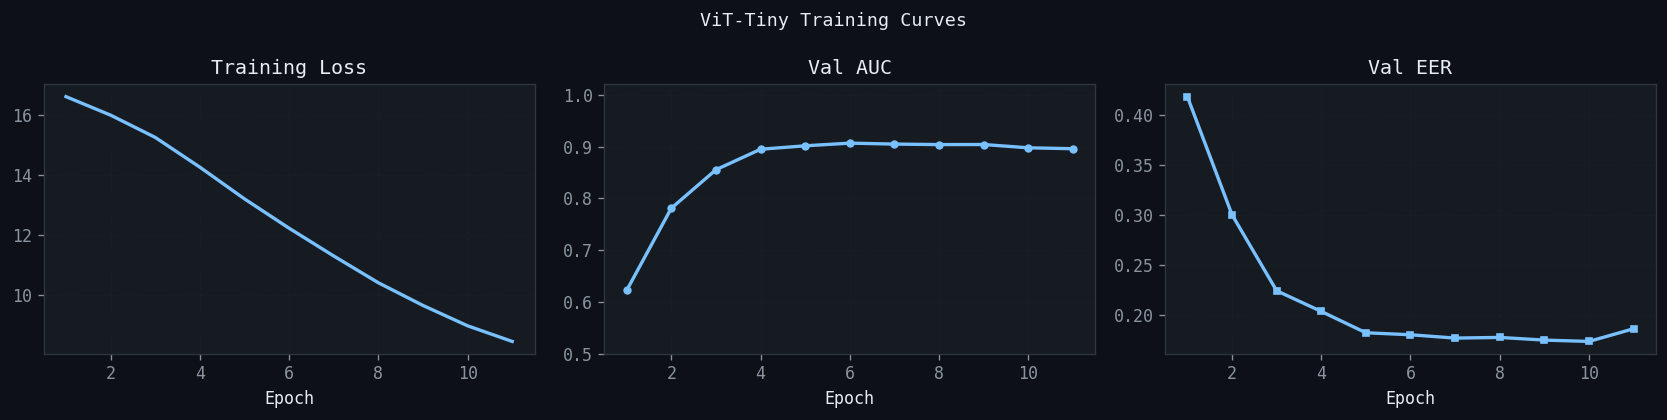

  fig_blok9_vit_tiny_curves.png saved ✓


In [12]:
# BLOK 9: Training ViT-Tiny
# ViT-Tiny ~5.7M params, target Jetson Nano 4GB

gc.collect(); torch.cuda.empty_cache()

tiny_ckpt_path = CFG['OUTPUT_DIR'] / 'vit_tiny_best.pth'

if tiny_ckpt_path.exists():
    print(f'  Checkpoint ada → skip training')
    _ck = torch.load(tiny_ckpt_path, map_location='cpu', weights_only=False)
    print(f'  val_AUC={_ck["val_auc"]:.4f} | epoch={_ck["epoch"]+1}')
    del _ck
    tiny_history = {'train_loss':[],'val_auc':[],'val_eer':[],'val_acc':[],'lr':[]}
else:
    # Instantiate baru — TIDAK pakai DataParallel
    vit_tiny = FaceEmbedder('vit_tiny', CFG['EMBEDDING_DIM']).to(DEVICE)
    print(f'  Model di GPU: {next(vit_tiny.parameters()).device}')
    tiny_history, tiny_ckpt_path = train_model(
        vit_tiny, 'vit_tiny', train_loader,
        val_pairs, val_labels, CFG,
        lr=CFG['LR'], warmup_ratio=CFG['WARMUP_RATIO'],
    )
    del vit_tiny

gc.collect(); torch.cuda.empty_cache()
ram = psutil.virtual_memory()
print(f'  RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB | '
      f'VRAM: {torch.cuda.memory_allocated()/1e9:.3f} GB')
print(f'  BLOK 9 selesai ✓')


# ── Visualisasi BLOK 9: Training curve ViT-Tiny ──────────────────────────
if tiny_history and tiny_history.get('train_loss'):
    plt.rcParams.update(PLT_STYLE)
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    ep = range(1, len(tiny_history['train_loss']) + 1)
    axes[0].plot(ep, tiny_history['train_loss'], color=CLR['tiny'], lw=2)
    axes[0].set_title('Training Loss',  color='#e6edf3')
    axes[1].plot(ep, tiny_history['val_auc'],   color=CLR['tiny'], lw=2, marker='o', ms=4)
    axes[1].set_title('Val AUC',        color='#e6edf3')
    axes[1].set_ylim([0.5, 1.02])
    axes[2].plot(ep, tiny_history['val_eer'],   color=CLR['tiny'], lw=2, marker='s', ms=4)
    axes[2].set_title('Val EER',        color='#e6edf3')
    for ax in axes:
        ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
    plt.suptitle('ViT-Tiny Training Curves', color='#e6edf3', fontsize=11)
    plt.tight_layout()
    save_show(fig, 'fig_blok9_vit_tiny_curves.png', 'ViT-Tiny Training Curves')
else:
    print("  Visualisasi skip — training di-skip (checkpoint sudah ada)")

## BLOK 10 — Eksekusi Training: ViT-Small (Skenario 1)

  Model di GPU: cuda:0
  Model verified di cuda:0 ✓

  Training: vit_small | LR=0.0001 | warmup=20% | epochs=15
  Batch=64 | Steps/epoch=137 | n_ids=350


  Ep 01/15:   0%|          | 0/137 [00:00<?, ?it/s]

  [   BEST   ] ep=01 | loss=16.5107 | AUC=0.8202 | EER=0.2593 | TAR@1%=0.1773 | 49s | VRAM=0.4GB


  Ep 02/15:   0%|          | 0/137 [00:00<?, ?it/s]

  [   BEST   ] ep=02 | loss=15.4189 | AUC=0.8937 | EER=0.1987 | TAR@1%=0.2907 | 48s | VRAM=0.4GB


...

  [ pat 3/5  ] ep=08 | loss=5.7576 | AUC=0.8990 | EER=0.1947 | TAR@1%=0.5213 | 49s | VRAM=0.4GB


  Ep 09/15:   0%|          | 0/137 [00:00<?, ?it/s]

  [ pat 4/5  ] ep=09 | loss=4.5537 | AUC=0.8995 | EER=0.1853 | TAR@1%=0.5413 | 49s | VRAM=0.4GB


  Ep 10/15:   0%|          | 0/137 [00:00<?, ?it/s]

  [ pat 5/5  ] ep=10 | loss=3.6269 | AUC=0.8955 | EER=0.1913 | TAR@1%=0.5253 | 49s | VRAM=0.4GB
  Early stop di epoch 10

  Selesai. Best val AUC: 0.9172 → vit_small_best.pth
  VRAM setelah cleanup: 0.200 GB
  RAM: 2.8/33.7 GB | VRAM: 0.018 GB
  BLOK 10 selesai ✓
  ── ViT-Small Training Curves


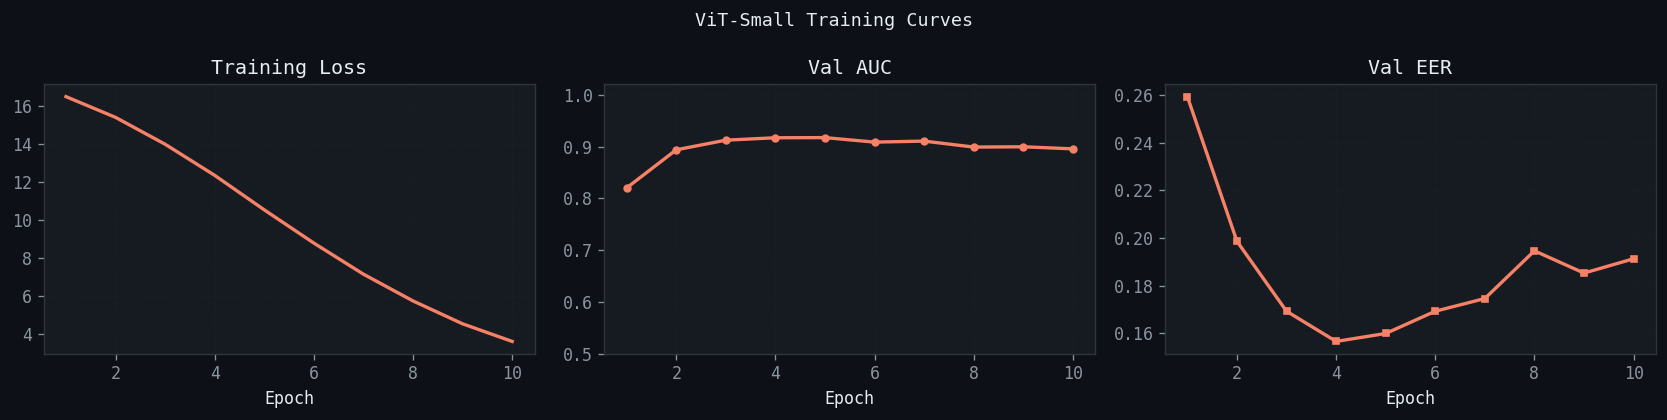

  fig_blok10_vit_small_curves.png saved ✓


In [13]:
# BLOK 10: Training ViT-Small
# ViT-Small ~22M params

gc.collect(); torch.cuda.empty_cache()

small_ckpt_path = CFG['OUTPUT_DIR'] / 'vit_small_best.pth'

if small_ckpt_path.exists():
    print(f'  Checkpoint ada → skip training')
    _ck = torch.load(small_ckpt_path, map_location='cpu', weights_only=False)
    print(f'  val_AUC={_ck["val_auc"]:.4f} | epoch={_ck["epoch"]+1}')
    del _ck
    small_history = {'train_loss':[],'val_auc':[],'val_eer':[],'val_acc':[],'lr':[]}
else:
    vit_small = FaceEmbedder('vit_small', CFG['EMBEDDING_DIM']).to(DEVICE)
    print(f'  Model di GPU: {next(vit_small.parameters()).device}')
    small_history, small_ckpt_path = train_model(
        vit_small, 'vit_small', train_loader,
        val_pairs, val_labels, CFG,
        lr=CFG['LR'], warmup_ratio=CFG['WARMUP_RATIO'],
    )
    del vit_small

gc.collect(); torch.cuda.empty_cache()
ram = psutil.virtual_memory()
print(f'  RAM: {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB | '
      f'VRAM: {torch.cuda.memory_allocated()/1e9:.3f} GB')
print(f'  BLOK 10 selesai ✓')


# ── Visualisasi BLOK 10: Training curve ViT-Small ─────────────────────────
if small_history and small_history.get('train_loss'):
    plt.rcParams.update(PLT_STYLE)
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    ep = range(1, len(small_history['train_loss']) + 1)
    axes[0].plot(ep, small_history['train_loss'], color=CLR['small'], lw=2)
    axes[0].set_title('Training Loss', color='#e6edf3')
    axes[1].plot(ep, small_history['val_auc'],    color=CLR['small'], lw=2, marker='o', ms=4)
    axes[1].set_title('Val AUC',       color='#e6edf3')
    axes[1].set_ylim([0.5, 1.02])
    axes[2].plot(ep, small_history['val_eer'],    color=CLR['small'], lw=2, marker='s', ms=4)
    axes[2].set_title('Val EER',       color='#e6edf3')
    for ax in axes:
        ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
    plt.suptitle('ViT-Small Training Curves', color='#e6edf3', fontsize=11)
    plt.tight_layout()
    save_show(fig, 'fig_blok10_vit_small_curves.png', 'ViT-Small Training Curves')
else:
    print("  Visualisasi skip — training di-skip (checkpoint sudah ada)")

## BLOK 11 — Eksekusi Training: MobileNetV2 — Baseline CNN (Skenario 1)

  mobilenet_v2 tidak ditemukan → instantiate baru
  Model device  : cuda:0
  backbone_key  : mobilenet_v2
  Type          : FaceEmbedder
  Params        : 2.9M
  Forward test  : (2, 512) | norm=1.0000 ✓
  DataLoader    : 137 steps | batch=64
  Loader test   : (64, 3, 224, 224) | device=cuda:0 ✓
  val_pairs     : 1,500 pairs ✓

  Semua verifikasi passed → mulai training...
  Model verified di cuda:0 ✓

  Training: mobilenet_v2 | LR=0.0005 | warmup=10% | epochs=15
  Batch=64 | Steps/epoch=137 | n_ids=350


  Ep 01/15:   0%|          | 0/137 [00:00<?, ?it/s]

  [   BEST   ] ep=01 | loss=16.3867 | AUC=0.7134 | EER=0.3560 | TAR@1%=0.1107 | 83s | VRAM=0.1GB


  Ep 02/15:   0%|          | 0/137 [00:00<?, ?it/s]

  [   BEST   ] ep=02 | loss=14.6980 | AUC=0.8323 | EER=0.2507 | TAR@1%=0.1720 | 45s | VRAM=0.1GB


...

  [ pat 3/5  ] ep=09 | loss=2.6661 | AUC=0.8703 | EER=0.2093 | TAR@1%=0.4387 | 45s | VRAM=0.1GB


  Ep 10/15:   0%|          | 0/137 [00:00<?, ?it/s]

  [ pat 4/5  ] ep=10 | loss=1.9863 | AUC=0.8600 | EER=0.2293 | TAR@1%=0.3787 | 46s | VRAM=0.1GB


  Ep 11/15:   0%|          | 0/137 [00:00<?, ?it/s]

  [ pat 5/5  ] ep=11 | loss=1.5512 | AUC=0.8628 | EER=0.2227 | TAR@1%=0.3813 | 46s | VRAM=0.1GB
  Early stop di epoch 11

  Selesai. Best val AUC: 0.8864 → mobilenet_v2_best.pth
  VRAM setelah cleanup: 0.042 GB

  Cleanup: RAM 3.5/33.7 GB | VRAM 0.018 GB
  BLOK 11 selesai ✓ → mobilenet_v2_best.pth
  Semua 3 model selesai dilatih.
  ── MobileNetV2 Training Curves


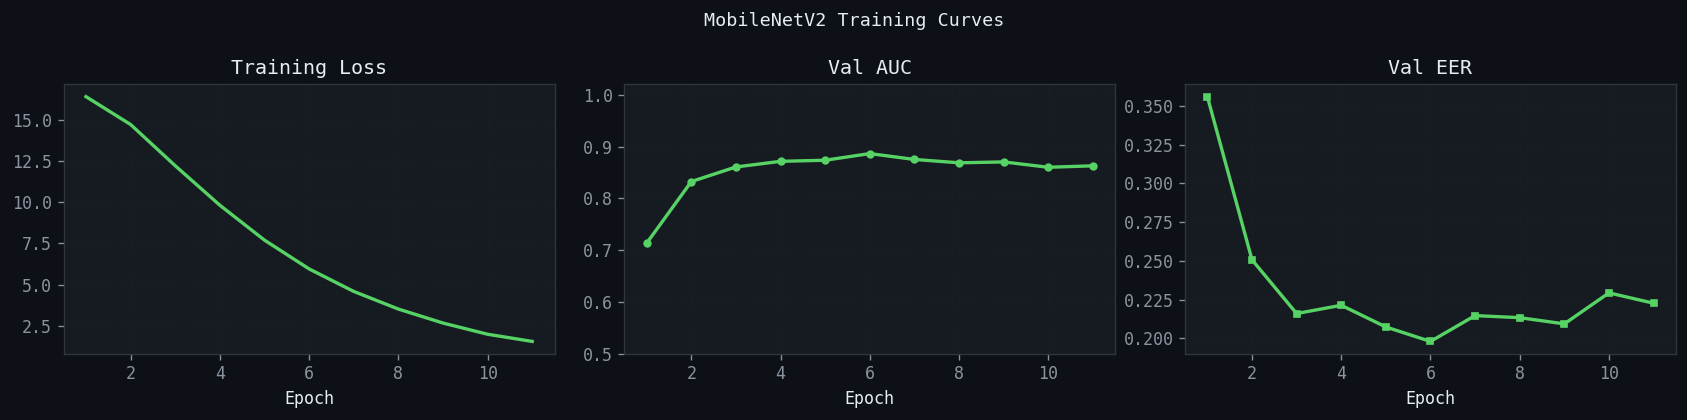

  fig_blok11_mobilenet_curves.png saved ✓
  ── Perbandingan 3 Backbone


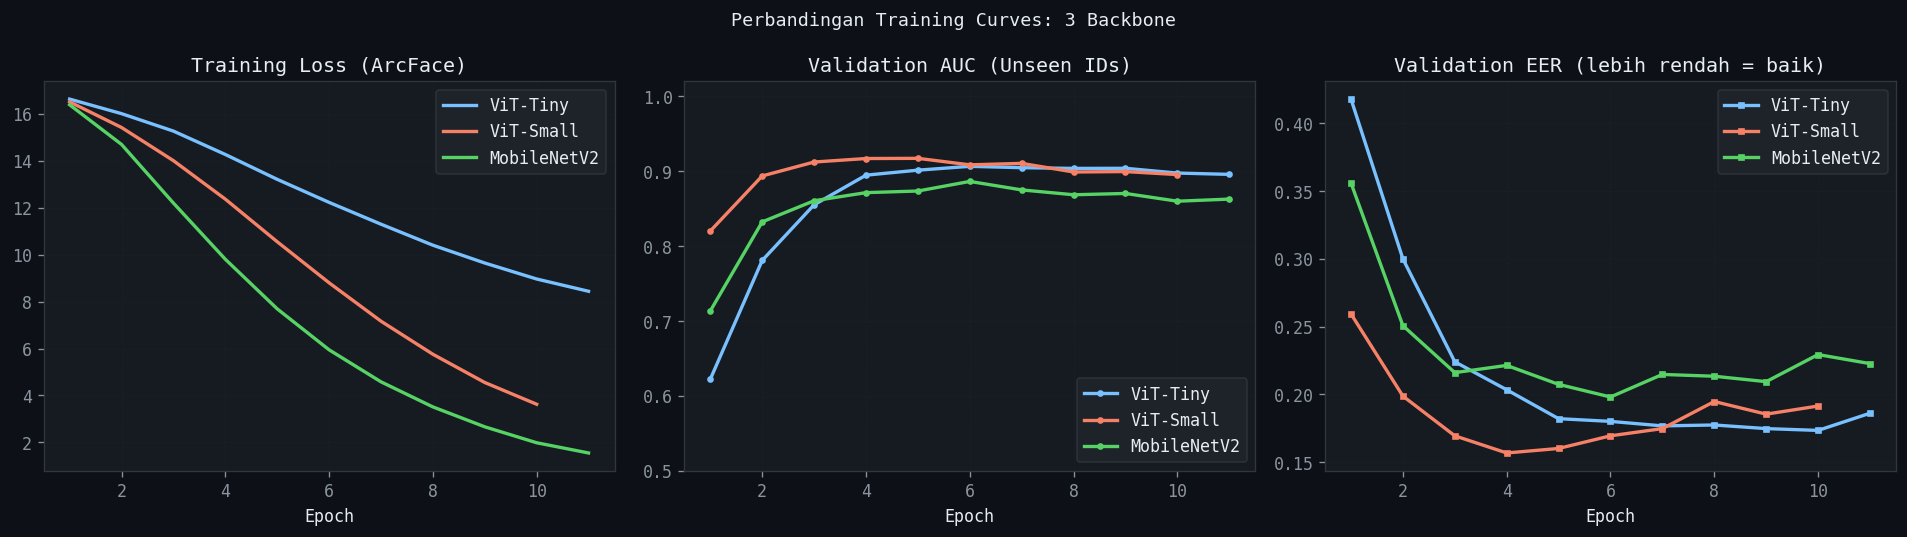

  fig1_training_curves.png saved ✓


In [14]:
# BLOK 11: Training MobileNetV2 — Baseline CNN (Skenario 1)
# FIX: Unwrap DataParallel + verifikasi GPU berlapis + instantiate bersih

import gc, psutil
gc.collect()
torch.cuda.empty_cache()

mob_ckpt_path = CFG['OUTPUT_DIR'] / 'mobilenet_v2_best.pth'

if mob_ckpt_path.exists():
    print(f'  Checkpoint ada → skip training')
    _ck = torch.load(mob_ckpt_path, map_location='cpu', weights_only=False)
    print(f'  val_AUC={_ck["val_auc"]:.4f} | epoch={_ck["epoch"]+1}')
    del _ck
    mob_history = {'train_loss':[],'val_auc':[],'val_eer':[],'val_acc':[],'lr':[]}

else:
    # ── Step 1: Pastikan mobilenet_v2 bersih dari DataParallel ───────────
    if 'mobilenet_v2' not in dir() or mobilenet_v2 is None:
        # Kalau variabel tidak ada sama sekali, buat baru
        print('  mobilenet_v2 tidak ditemukan → instantiate baru')
        mobilenet_v2 = FaceEmbedder('mobilenet_v2', CFG['EMBEDDING_DIM']).to(DEVICE)
    elif isinstance(mobilenet_v2, nn.DataParallel):
        # Unwrap DataParallel dari versi notebook lama
        print('  Unwrapping DataParallel dari mobilenet_v2...')
        mobilenet_v2 = mobilenet_v2.module.to(DEVICE)
    else:
        # Sudah clean, pastikan di GPU yang benar
        mobilenet_v2 = mobilenet_v2.to(DEVICE)

    # ── Step 2: Verifikasi model di GPU ──────────────────────────────────
    _param_dev = next(mobilenet_v2.parameters()).device
    print(f'  Model device  : {_param_dev}')
    assert _param_dev.type == 'cuda', \
        f"ERROR: Model di {_param_dev}, bukan CUDA! Restart kernel dan jalankan ulang."

    # ── Step 3: Verifikasi backbone_key accessible ────────────────────────
    print(f'  backbone_key  : {mobilenet_v2.backbone_key}')
    print(f'  Type          : {type(mobilenet_v2).__name__}')
    print(f'  Params        : {mobilenet_v2.count_params()/1e6:.1f}M')

    # ── Step 4: Verifikasi forward pass di GPU ────────────────────────────
    mobilenet_v2.eval()
    with torch.no_grad():
        _x   = torch.randn(2, 3, CFG['IMG_SIZE'], CFG['IMG_SIZE']).to(DEVICE)
        _out = mobilenet_v2(_x)
        assert _out.device.type == 'cuda', "Output tidak di CUDA!"
        assert abs(_out.norm(dim=1).mean().item() - 1.0) < 0.01, "L2 norm tidak ~1.0!"
        print(f'  Forward test  : {tuple(_out.shape)} | norm={_out.norm(dim=1).mean():.4f} ✓')
    del _x, _out

    # ── Step 5: Verifikasi DataLoader masih valid ─────────────────────────
    print(f'  DataLoader    : {len(train_loader)} steps | batch={CFG["BATCH_SIZE"]}')
    _imgs, _lbls = next(iter(train_loader))
    _imgs_gpu    = _imgs.to(DEVICE)
    print(f'  Loader test   : {tuple(_imgs_gpu.shape)} | device={_imgs_gpu.device} ✓')
    del _imgs, _lbls, _imgs_gpu

    # ── Step 6: Verifikasi val_pairs tersedia ────────────────────────────
    assert len(val_pairs) > 0,  "val_pairs kosong! Jalankan BLOK 8 dulu."
    assert len(val_labels) > 0, "val_labels kosong! Jalankan BLOK 8 dulu."
    print(f'  val_pairs     : {len(val_pairs):,} pairs ✓')

    # ── Step 7: Training ──────────────────────────────────────────────────
    mobilenet_v2.train()
    print(f'\n  Semua verifikasi passed → mulai training...')

    mob_history, mob_ckpt_path = train_model(
        mobilenet_v2, 'mobilenet_v2', train_loader,
        val_pairs, val_labels, CFG,
        lr=CFG['LR_CNN'], warmup_ratio=CFG['WARMUP_RATIO_CNN'],
    )
    del mobilenet_v2

# ── Cleanup ───────────────────────────────────────────────────────────────
gc.collect()
torch.cuda.empty_cache()

ram  = psutil.virtual_memory()
vram = torch.cuda.memory_allocated() / 1e9
print(f'\n  Cleanup: RAM {ram.used/1e9:.1f}/{ram.total/1e9:.1f} GB | VRAM {vram:.3f} GB')
print(f'  BLOK 11 selesai ✓ → {mob_ckpt_path.name}')
print(f'  Semua 3 model selesai dilatih.')


# ── Visualisasi BLOK 11: Training curve MobileNetV2 ───────────────────────
if mob_history and mob_history.get('train_loss'):
    plt.rcParams.update(PLT_STYLE)
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
    ep = range(1, len(mob_history['train_loss']) + 1)
    axes[0].plot(ep, mob_history['train_loss'], color=CLR['mob'], lw=2)
    axes[0].set_title('Training Loss', color='#e6edf3')
    axes[1].plot(ep, mob_history['val_auc'],    color=CLR['mob'], lw=2, marker='o', ms=4)
    axes[1].set_title('Val AUC',       color='#e6edf3')
    axes[1].set_ylim([0.5, 1.02])
    axes[2].plot(ep, mob_history['val_eer'],    color=CLR['mob'], lw=2, marker='s', ms=4)
    axes[2].set_title('Val EER',       color='#e6edf3')
    for ax in axes:
        ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
    plt.suptitle('MobileNetV2 Training Curves', color='#e6edf3', fontsize=11)
    plt.tight_layout()
    save_show(fig, 'fig_blok11_mobilenet_curves.png', 'MobileNetV2 Training Curves')

    # Perbandingan 3 model jika semua sudah selesai
    histories_ready = (
        tiny_history  and tiny_history.get('train_loss') and
        small_history and small_history.get('train_loss') and
        mob_history   and mob_history.get('train_loss')
    )
    if histories_ready:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
        for mname, mhist, clr in [
            ('ViT-Tiny',    tiny_history,  CLR['tiny']),
            ('ViT-Small',   small_history, CLR['small']),
            ('MobileNetV2', mob_history,   CLR['mob']),
        ]:
            ep = range(1, len(mhist['train_loss']) + 1)
            axes[0].plot(ep, mhist['train_loss'], color=clr, label=mname, lw=2)
            axes[1].plot(ep, mhist['val_auc'],    color=clr, label=mname, lw=2, marker='o', ms=3)
            axes[2].plot(ep, mhist['val_eer'],    color=clr, label=mname, lw=2, marker='s', ms=3)
        axes[0].set_title('Training Loss (ArcFace)',             color='#e6edf3')
        axes[1].set_title('Validation AUC (Unseen IDs)',          color='#e6edf3')
        axes[2].set_title('Validation EER (lebih rendah = baik)', color='#e6edf3')
        for ax in axes:
            ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
        axes[1].set_ylim([0.5, 1.02])
        plt.suptitle('Perbandingan Training Curves: 3 Backbone', color='#e6edf3', fontsize=11)
        plt.tight_layout()
        save_show(fig, 'fig1_training_curves.png', 'Perbandingan 3 Backbone')
else:
    print("  Visualisasi skip — training di-skip (checkpoint sudah ada)")

## BLOK 12 — Evaluasi Skenario 1: Akurasi Verifikasi Baseline (Clean)

Evaluasi pada test set identitas yang **tidak pernah dilihat saat training**.  
Metrik utama (Bab 3.8, Tabel 3.5): AUC, EER, Accuracy, Precision, Recall, F1, TAR@FAR=1% dan 0.1%


  BLOK 12 — Evaluasi Skenario 1: Baseline Verifikasi (Clean)
  [ViT-Tiny] val_AUC=0.9066 → evaluasi 6,000 pairs...
  [ViT-Tiny] AUC=0.8956 | EER=0.1820 | TAR@1%=0.2853 | TAR@0.1%=0.0707
  [ViT-Small] val_AUC=0.9172 → evaluasi 6,000 pairs...
  [ViT-Small] AUC=0.9104 | EER=0.1650 | TAR@1%=0.3463 | TAR@0.1%=0.1607
  [MobileNetV2] val_AUC=0.8864 → evaluasi 6,000 pairs...
  [MobileNetV2] AUC=0.8725 | EER=0.2045 | TAR@1%=0.3777 | TAR@0.1%=0.2220

  Metrik                       ViT-Tiny      ViT-Small    MobileNetV2
  ---------------------------------------------------------------------------
  AUC                            0.8956         0.9104         0.8725
  EER                            0.1820         0.1650         0.2045
  Accuracy @ EER                 0.8180         0.8350         0.7955
  Precision @ EER                0.8180         0.8350         0.7956
  Recall @ EER                   0.8180         0.8350         0.7953
  F1 @ EER                       0.8180         0.8350   

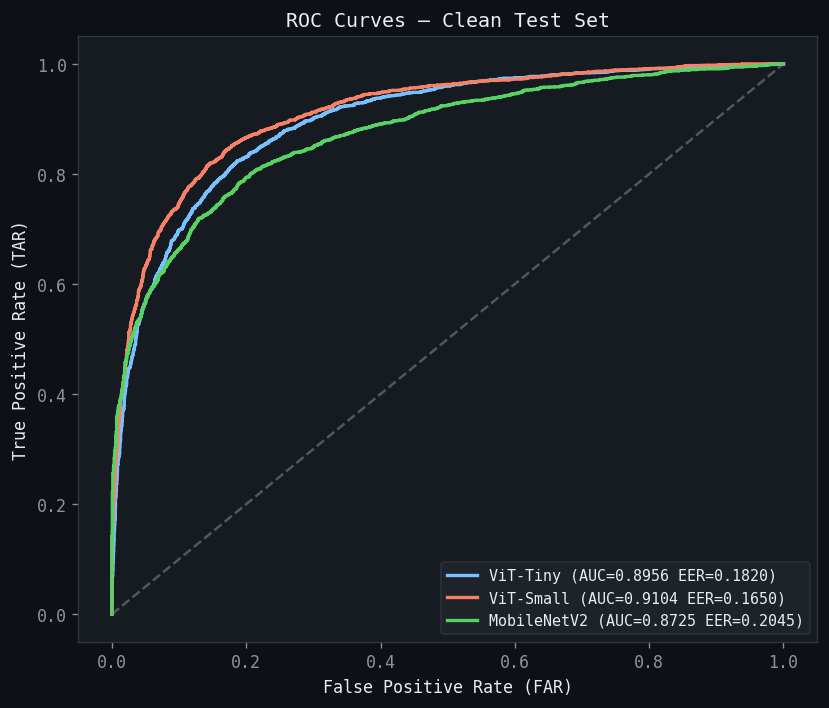

  fig2_roc_curves.png saved ✓
  ── Metrik Baseline per Model


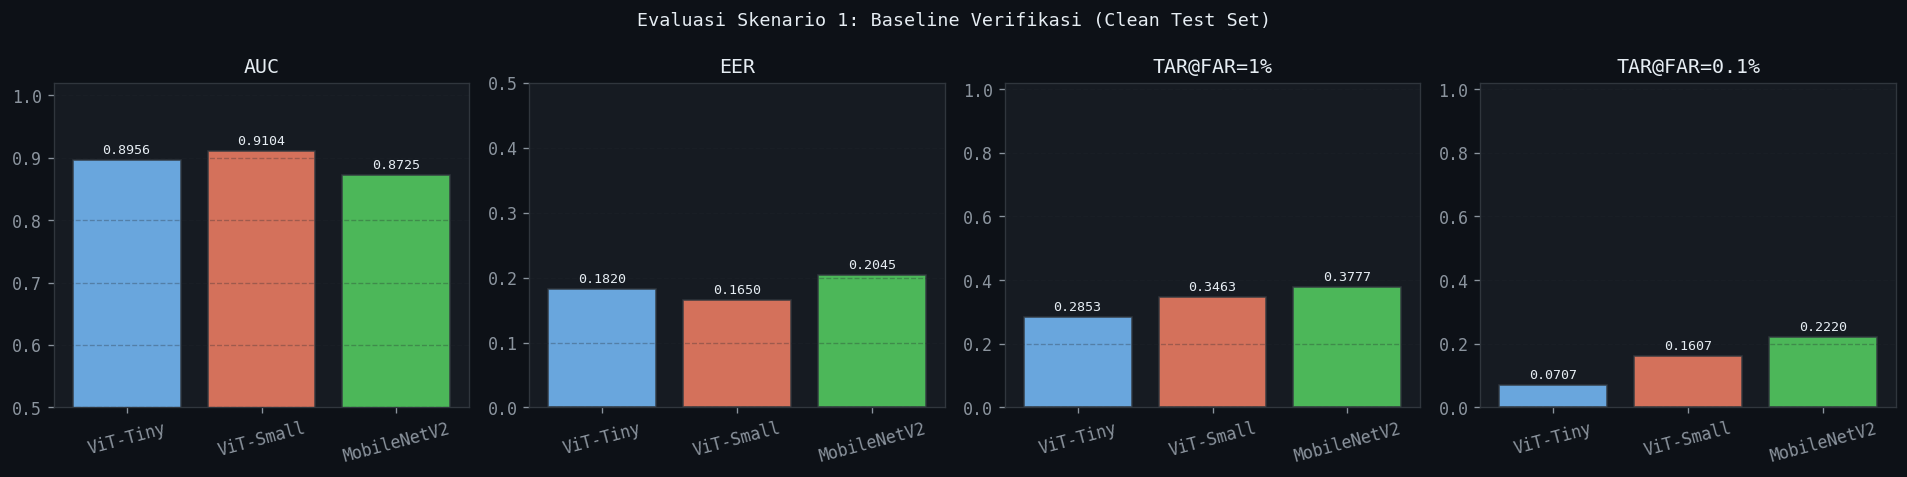

  fig_blok12_metrics_bar.png saved ✓

  BLOK 12 selesai ✓


In [15]:
# BLOK 12: Evaluasi Skenario 1 — Baseline Verifikasi (Clean)
# Load satu model per saat → eval → del → load berikutnya
# Hemat VRAM, tidak ada 3 model di GPU bersamaan

import gc

print("=" * 70)
print("  BLOK 12 — Evaluasi Skenario 1: Baseline Verifikasi (Clean)")
print("=" * 70)

def eval_single(ckpt_path, name, pairs, labels):
    """Load → eval → del model. Return (metrics_dict, ckpt_dict)."""
    model, ckpt = load_best_model(ckpt_path)
    print(f'  [{name}] val_AUC={ckpt["val_auc"]:.4f} → evaluasi {len(pairs):,} pairs...')
    res = evaluate_pairs(model, pairs, labels, full_arrays=True)
    print(f'  [{name}] AUC={res["auc"]:.4f} | EER={res["eer"]:.4f} | '
          f'TAR@1%={res["tar_far_1pct"]:.4f} | TAR@0.1%={res["tar_far_01pct"]:.4f}')
    del model
    gc.collect()
    torch.cuda.empty_cache()
    return res, ckpt

# Evaluasi satu per satu — tidak ada 3 model di GPU bersamaan
tiny_test,  tiny_ckpt  = eval_single(tiny_ckpt_path,  'ViT-Tiny',    test_pairs, test_labels)
small_test, small_ckpt = eval_single(small_ckpt_path, 'ViT-Small',   test_pairs, test_labels)
mob_test,   mob_ckpt   = eval_single(mob_ckpt_path,   'MobileNetV2', test_pairs, test_labels)

# Tabel ringkasan
print(f'\n  {"=" * 75}')
print(f'  {"Metrik":<22} {"ViT-Tiny":>14} {"ViT-Small":>14} {"MobileNetV2":>14}')
print(f'  {"-" * 75}')
for key, label in [
    ('auc',           'AUC'),
    ('eer',           'EER'),
    ('accuracy',      'Accuracy @ EER'),
    ('precision',     'Precision @ EER'),
    ('recall',        'Recall @ EER'),
    ('f1',            'F1 @ EER'),
    ('tar_far_1pct',  'TAR@FAR=1%'),
    ('tar_far_01pct', 'TAR@FAR=0.1%'),
]:
    print(f'  {label:<22} '
          f'{tiny_test[key]:>14.4f} '
          f'{small_test[key]:>14.4f} '
          f'{mob_test[key]:>14.4f}')
print(f'  {"-" * 75}')
print(f'  {"Threshold (EER)":<22} '
      f'{tiny_test["threshold"]:>14.4f} '
      f'{small_test["threshold"]:>14.4f} '
      f'{mob_test["threshold"]:>14.4f}')
print(f'  {"=" * 75}')

# Simpan threshold untuk kalibrasi edge (Bab 3.7)
THRESHOLDS = {
    'vit_tiny'    : tiny_ckpt['val_threshold'],
    'vit_small'   : small_ckpt['val_threshold'],
    'mobilenet_v2': mob_ckpt['val_threshold'],
}
print(f'\n  Threshold kalibrasi dari val set:')
for k, v in THRESHOLDS.items():
    print(f'    {k:<16}: {v:.4f}')

# ── Visualisasi BLOK 12 ───────────────────────────────────────────────────
plt.rcParams.update(PLT_STYLE)

# ROC Curves
fig, ax = plt.subplots(figsize=(7, 6))
for mname, mtest, clr in [
    ('ViT-Tiny',    tiny_test,  CLR['tiny']),
    ('ViT-Small',   small_test, CLR['small']),
    ('MobileNetV2', mob_test,   CLR['mob']),
]:
    if 'fpr' in mtest and 'tpr' in mtest:
        ax.plot(mtest['fpr'], mtest['tpr'], color=clr, lw=2,
                label=f'{mname} (AUC={mtest["auc"]:.4f} EER={mtest["eer"]:.4f})')
ax.plot([0,1],[0,1],'--', color='#8b949e', alpha=0.5)
ax.set_xlabel('False Positive Rate (FAR)')
ax.set_ylabel('True Positive Rate (TAR)')
ax.set_title('ROC Curves — Clean Test Set', color='#e6edf3')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
save_show(fig, 'fig2_roc_curves.png', 'ROC Curves — Clean Test Set')

# Bar chart metrik ringkasan
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
models = ['ViT-Tiny', 'ViT-Small', 'MobileNetV2']
colors = [CLR['tiny'], CLR['small'], CLR['mob']]
tests  = [tiny_test, small_test, mob_test]

for ax, (key, lbl, ylim) in zip(axes, [
    ('auc',           'AUC',         (0.5, 1.02)),
    ('eer',           'EER',         (0.0, 0.5)),
    ('tar_far_1pct',  'TAR@FAR=1%',  (0.0, 1.02)),
    ('tar_far_01pct', 'TAR@FAR=0.1%',(0.0, 1.02)),
]):
    vals = [t[key] for t in tests]
    bars = ax.bar(models, vals, color=colors, alpha=0.85, edgecolor='#30363d')
    ax.set_title(lbl, color='#e6edf3')
    ax.set_ylim(ylim)
    ax.grid(alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (ylim[1] - ylim[0]) * 0.02,
            f'{v:.4f}', ha='center', fontsize=8, color='#e6edf3'
        )

plt.suptitle('Evaluasi Skenario 1: Baseline Verifikasi (Clean Test Set)',
             color='#e6edf3', fontsize=11)
plt.tight_layout()
save_show(fig, 'fig_blok12_metrics_bar.png', 'Metrik Baseline per Model')

print(f'\n  BLOK 12 selesai ✓')

## BLOK 13 — Evaluasi Skenario 2: Robustness terhadap Perturbasi Nyata

Mengimplementasikan benchmark perturbasi yang diadaptasi dari ImageNet-C (Hendrycks & Dietterich, 2019),  
dipilih berdasarkan relevansi kondisi deployment pada edge device:

| Perturbasi | Relevansi |
|---|---|
| Low-light (γ=2.5) | Ruangan dengan pencahayaan minim |
| Overexposure (γ=0.5) | Kamera menghadap cahaya langsung |
| Motion blur (k=9) | Subjek bergerak atau kamera bergetar |
| Gaussian blur (σ=3) | Fokus kamera tidak tepat |
| Occlusion 25% | Masker, tangan, atau objek menutupi wajah |
| JPEG q=20 | Kompresi tinggi dari webcam/streaming |
| Rotation ±15° | Pose kepala tidak frontal |
| Webcam sim | Downsample 64px + blur σ=1.5 (simulasi webcam murah) |


  [ViT-Tiny]
  Kondisi                     AUC      EER    TAR@1%   TAR@0.1%     ΔAUC
  ----------------------------------------------------------------------
  clean                    0.8956   0.1820    0.2853     0.0707  +0.0000
  low_light_g2.5           0.8695   0.2107    0.2333     0.0860  -0.0262
  overexpose_g0.5          0.8797   0.1998    0.2143     0.0837  -0.0160
  motion_blur_k9           0.8906   0.1877    0.2650     0.0780  -0.0050
  gaussian_blur_s3         0.8809   0.2020    0.2533     0.0783  -0.0147
  occlusion_25pct          0.8607   0.2215    0.2030     0.0737  -0.0350
  jpeg_q20                 0.8830   0.1957    0.2810     0.0890  -0.0126
  rotation_15deg           0.8908   0.1870    0.2613     0.0637  -0.0048
  webcam_sim               0.8881   0.1927    0.2583     0.0793  -0.0075

  [ViT-Small]
  Kondisi                     AUC      EER    TAR@1%   TAR@0.1%     ΔAUC
  ----------------------------------------------------------------------
  clean               

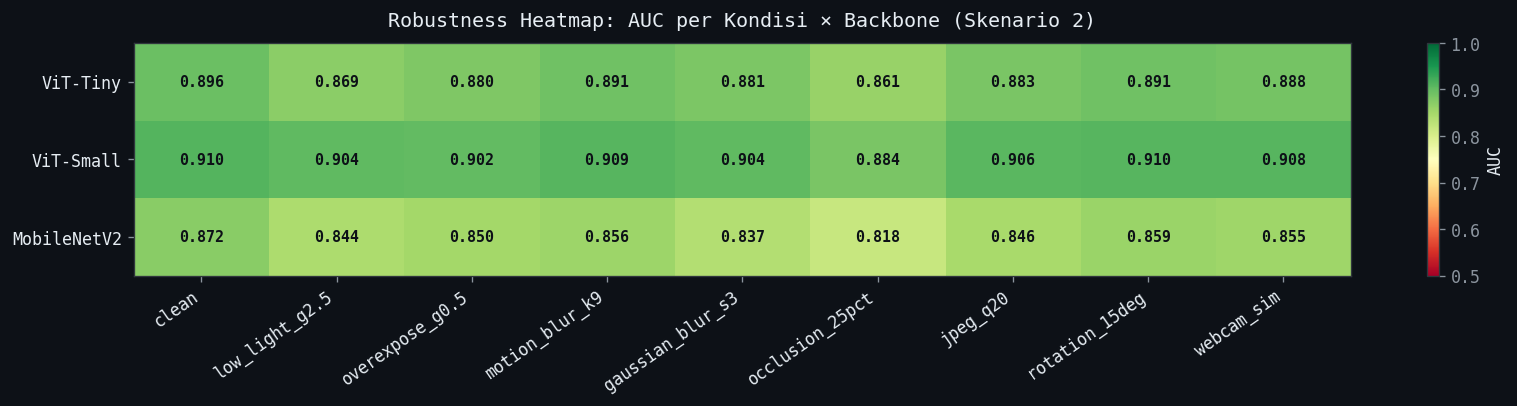

  fig3_robustness_heatmap.png saved ✓
  ── AUC Drop per Perturbasi


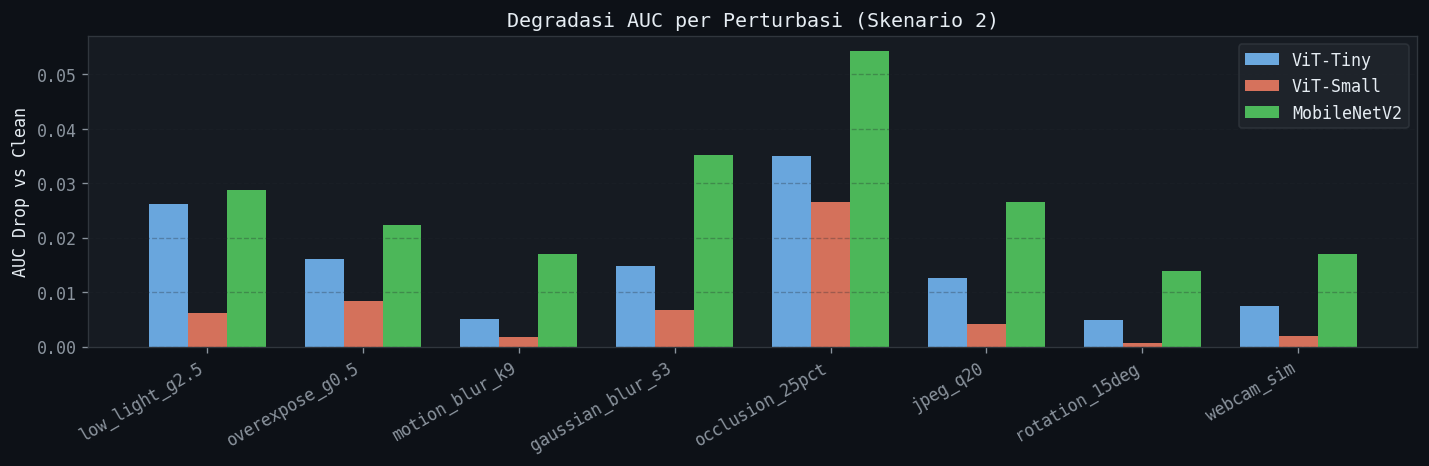

  fig_blok13_auc_drop.png saved ✓

  BLOK 13 selesai ✓


In [16]:
# ── Ganti bagian ini di BLOK 13 ──────────────────────────────────────────
# LAMA — pakai variabel yang tidak ada
# robust_tiny  = run_robustness_eval(vit_tiny_best,  'ViT-Tiny',    ...)
# robust_small = run_robustness_eval(vit_small_best, 'ViT-Small',   ...)
# robust_mob   = run_robustness_eval(mob_best,       'MobileNetV2', ...)

class RealWorldPerturbation:
    """
    Simulasi kondisi nyata yang dihadapi sistem absensi di edge device.
    Diadaptasi dari ImageNet-C (Hendrycks & Dietterich, 2019).
    """

    @staticmethod
    def gamma(img, g):
        table = np.array([((i / 255.0) ** (1.0 / g)) * 255
                          for i in range(256)]).astype('uint8')
        return cv2.LUT(img, table)

    @staticmethod
    def motion_blur(img, k=9):
        kern = np.zeros((k, k)); kern[k // 2, :] = 1.0 / k
        return cv2.filter2D(img, -1, kern)

    @staticmethod
    def gaussian_blur(img, sigma=3):
        ks = int(2 * round(3 * sigma) + 1)
        return cv2.GaussianBlur(img, (ks, ks), sigma)

    @staticmethod
    def occlusion(img, ratio=0.25, seed=42):
        rng = np.random.RandomState(seed + hash(img.tobytes()) % 1000)
        h, w = img.shape[:2]
        sh, sw = int(h * ratio ** 0.5), int(w * ratio ** 0.5)
        y = rng.randint(0, max(1, h - sh))
        x = rng.randint(0, max(1, w - sw))
        out = img.copy(); out[y:y+sh, x:x+sw] = 0
        return out

    @staticmethod
    def jpeg(img, q=20):
        bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        _, enc = cv2.imencode('.jpg', bgr, [cv2.IMWRITE_JPEG_QUALITY, q])
        dec = cv2.imdecode(enc, cv2.IMREAD_COLOR)
        return cv2.cvtColor(dec, cv2.COLOR_BGR2RGB)

    @staticmethod
    def rotation(img, angle=15):
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

    @staticmethod
    def downsample(img, lo=64):
        h, w = img.shape[:2]
        s = cv2.resize(img, (lo, lo), interpolation=cv2.INTER_AREA)
        return cv2.resize(s, (w, h), interpolation=cv2.INTER_LINEAR)

    @staticmethod
    def webcam_sim(img):
        """Simulasi webcam murah: downsample 64px + gaussian blur.
        Merepresentasikan karakteristik Logitech C270 vs Sony IMX219.
        Justifikasi: Menezes et al. (2020) dokumentasikan drop 97%→51% antara
        iPhone dan webcam standar — perturbasi ini mencoba merepresentasikannya."""
        return RealWorldPerturbation.gaussian_blur(
            RealWorldPerturbation.downsample(img, 64), sigma=1.5)


P = RealWorldPerturbation
PERTURBATIONS = {
    'clean'           : None,
    'low_light_g2.5'  : lambda x: P.gamma(x, 2.5),
    'overexpose_g0.5' : lambda x: P.gamma(x, 0.5),
    'motion_blur_k9'  : lambda x: P.motion_blur(x, 9),
    'gaussian_blur_s3': lambda x: P.gaussian_blur(x, 3),
    'occlusion_25pct' : lambda x: P.occlusion(x, 0.25),
    'jpeg_q20'        : lambda x: P.jpeg(x, 20),
    'rotation_15deg'  : lambda x: P.rotation(x, 15),
    'webcam_sim'      : lambda x: P.webcam_sim(x),
}

# BARU — load satu model per saat, eval semua kondisi, del sebelum berikutnya
def run_robustness_eval_single(ckpt_path, name, pairs, labels):
    """
    Load model → eval semua perturbasi → del model.
    Hanya satu model di GPU setiap saat — hemat VRAM.
    full_arrays=False: hanya simpan scalars (tidak perlu fpr/tpr untuk robustness).
    """
    model, _ = load_best_model(ckpt_path)
    results  = {}
    base_auc = None

    print(f'\n  [{name}]')
    print(f'  {"Kondisi":<22} {"AUC":>8} {"EER":>8} '
          f'{"TAR@1%":>9} {"TAR@0.1%":>10} {"ΔAUC":>8}')
    print(f'  {"-" * 70}')

    for cond, fn in PERTURBATIONS.items():
        res   = evaluate_pairs(model, pairs, labels,
                               perturb_fn=fn, full_arrays=False)
        delta = 0.0 if base_auc is None else res['auc'] - base_auc
        if base_auc is None:
            base_auc = res['auc']

        print(f'  {cond:<22} {res["auc"]:>8.4f} {res["eer"]:>8.4f} '
              f'{res["tar_far_1pct"]:>9.4f} {res["tar_far_01pct"]:>10.4f} '
              f'{delta:>+8.4f}')

        # Simpan hanya scalars — tidak perlu fpr/tpr untuk robustness
        results[cond] = {
            'auc'          : res['auc'],
            'eer'          : res['eer'],
            'accuracy'     : res['accuracy'],
            'tar_far_1pct' : res['tar_far_1pct'],
            'tar_far_01pct': res['tar_far_01pct'],
            'threshold'    : res['threshold'],
        }
        del res

    del model
    gc.collect()
    torch.cuda.empty_cache()
    return results

robust_tiny  = run_robustness_eval_single(tiny_ckpt_path,  'ViT-Tiny',    test_pairs, test_labels)
robust_small = run_robustness_eval_single(small_ckpt_path, 'ViT-Small',   test_pairs, test_labels)
robust_mob   = run_robustness_eval_single(mob_ckpt_path,   'MobileNetV2', test_pairs, test_labels)

# ── Visualisasi BLOK 13 ───────────────────────────────────────────────────
plt.rcParams.update(PLT_STYLE)
cond_names = list(PERTURBATIONS.keys())

# Heatmap AUC
auc_matrix = np.array([
    [robust_tiny[c]['auc']  for c in cond_names],
    [robust_small[c]['auc'] for c in cond_names],
    [robust_mob[c]['auc']   for c in cond_names],
])
fig, ax = plt.subplots(figsize=(14, 3.5))
im = ax.imshow(auc_matrix, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
ax.set_xticks(range(len(cond_names)))
ax.set_xticklabels(cond_names, rotation=35, ha='right', color='#e6edf3')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['ViT-Tiny', 'ViT-Small', 'MobileNetV2'], color='#e6edf3')
for i in range(3):
    for j in range(len(cond_names)):
        ax.text(j, i, f'{auc_matrix[i,j]:.3f}',
                ha='center', va='center',
                color='#0d1117', fontweight='bold', fontsize=9)
plt.colorbar(im, ax=ax, label='AUC')
ax.set_title('Robustness Heatmap: AUC per Kondisi × Backbone (Skenario 2)',
             color='#e6edf3', pad=10)
plt.tight_layout()
save_show(fig, 'fig3_robustness_heatmap.png', 'Robustness Heatmap')

# AUC Drop bar chart
cond_p = [c for c in cond_names if c != 'clean']
x2     = np.arange(len(cond_p))
fig, ax = plt.subplots(figsize=(12, 4))
for i, (mname, robust, clr) in enumerate([
    ('ViT-Tiny',    robust_tiny,  CLR['tiny']),
    ('ViT-Small',   robust_small, CLR['small']),
    ('MobileNetV2', robust_mob,   CLR['mob']),
]):
    drops = [robust['clean']['auc'] - robust[c]['auc'] for c in cond_p]
    ax.bar(x2 + (i-1)*0.25, drops, 0.25, color=clr, label=mname, alpha=0.85)
ax.set_xticks(x2)
ax.set_xticklabels(cond_p, rotation=30, ha='right')
ax.set_ylabel('AUC Drop vs Clean')
ax.set_title('Degradasi AUC per Perturbasi (Skenario 2)', color='#e6edf3')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
save_show(fig, 'fig_blok13_auc_drop.png', 'AUC Drop per Perturbasi')

print(f'\n  BLOK 13 selesai ✓')

## BLOK 14 — Ablasi Skenario 3: Pengaruh Ukuran Subset Identitas

Mengukur sensitivitas performa terhadap jumlah identitas training: {300, 400, 500}.  
Hanya ViT-Tiny yang dilatih untuk semua ukuran (model tercepat, cukup untuk analisis tren).  
Backbone lain sudah dilatih pada 400 ID sebagai konfigurasi utama.

  Pool identitas: 350 ID
  Ablasi sizes  : [300, 400, 500]

  Ablasi n_ids=300
  VRAM sebelum: 0.142 GB
  IDs=210 | imgs=5,307 | classes=210
  Steps/epoch: 82
  Model device: cuda:0 ✓
    ep=05 | loss=12.7443 | val_AUC=0.8821 | val_EER=0.1993 | VRAM=0.23GB
    ep=10 | loss=8.4555 | val_AUC=0.8832 | val_EER=0.1973 | VRAM=0.23GB
    ep=15 | loss=7.0154 | val_AUC=0.8844 | val_EER=0.1887 | VRAM=0.23GB
  Cleanup: RAM=3.6GB | VRAM=0.142GB
  HASIL n_ids=300: AUC=0.8858 | EER=0.1980 | TAR@1%=0.2473

  Ablasi n_ids=400
  VRAM sebelum: 0.164 GB
  IDs=280 | imgs=7,002 | classes=280
  Steps/epoch: 109
  Model device: cuda:0 ✓
    ep=05 | loss=12.9169 | val_AUC=0.8995 | val_EER=0.1893 | VRAM=0.26GB
    ep=10 | loss=8.8879 | val_AUC=0.8995 | val_EER=0.1787 | VRAM=0.26GB
    ep=15 | loss=7.3901 | val_AUC=0.8943 | val_EER=0.1820 | VRAM=0.26GB
  Cleanup: RAM=3.6GB | VRAM=0.164GB
  HASIL n_ids=400: AUC=0.9027 | EER=0.1763 | TAR@1%=0.3120

  Ablasi n_ids=500
  VRAM sebelum: 0.164 GB
  IDs=350 | imgs=8,77

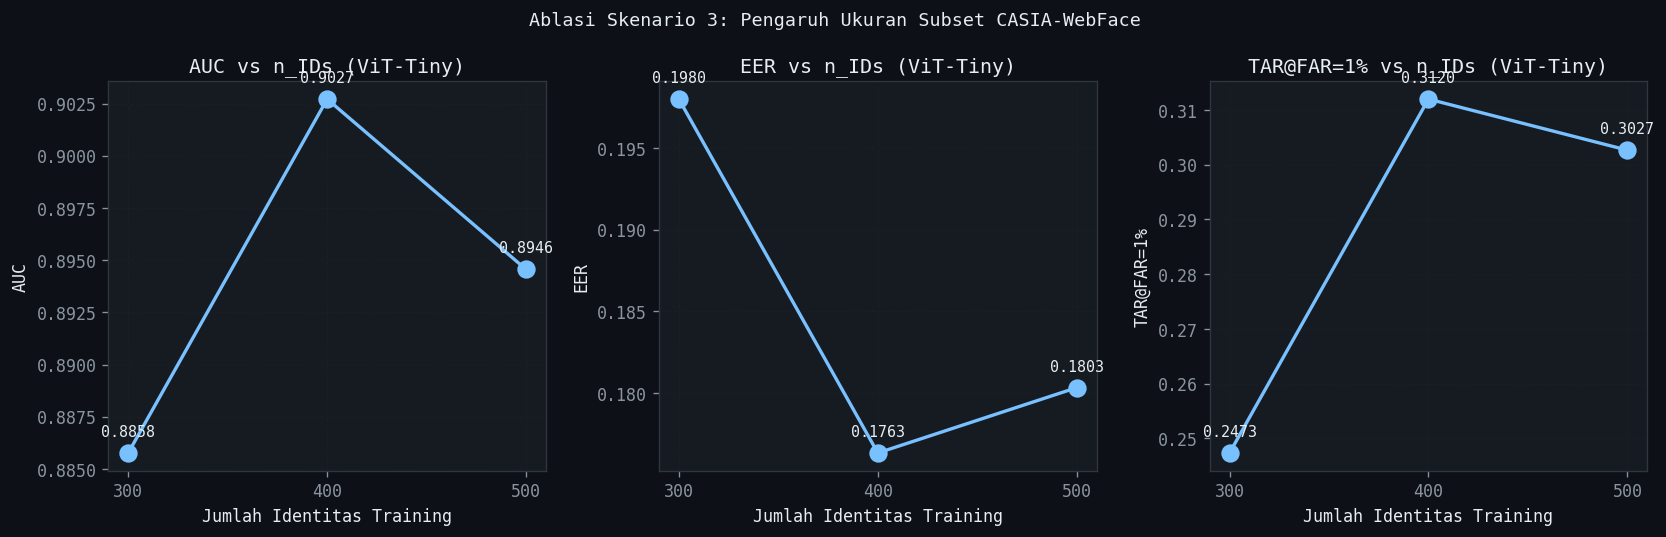

  fig5_ablation_subset.png saved ✓


In [17]:
# BLOK 14: Ablasi Skenario 3 — Pengaruh Subset Size {300, 400, 500}
# FIX: pakai make_autocast() dari BLOK 3 (kompatibel semua versi PyTorch)
# FIX: make_lr_lambda() hindari closure leak
# FIX: del abl_paths, abl_labels, emb setelah dipakai

import gc, psutil, math

ABLATION_SIZES   = [300, 400, 500]
ablation_results = {}

all_available_ids = sorted([d for d in CFG['JPG_DIR'].glob('id_*') if d.is_dir()])
val_test_set      = set(d.name for d in val_ids + test_ids)
pool_clean        = [d for d in all_available_ids
                     if d.name not in val_test_set
                     and len(list(d.glob('*.jpg'))) >= CFG['MIN_PER_ID']]

print(f"  Pool identitas: {len(pool_clean)} ID")
print(f"  Ablasi sizes  : {ABLATION_SIZES}")

for n_ids in ABLATION_SIZES:
    print(f'\n{"=" * 60}')
    print(f'  Ablasi n_ids={n_ids}')
    print(f'{"=" * 60}')

    gc.collect()
    torch.cuda.empty_cache()

    # Verifikasi GPU
    assert torch.cuda.is_available(), "CUDA tidak tersedia!"
    print(f"  VRAM sebelum: {torch.cuda.memory_allocated()/1e9:.3f} GB")

    # ── Bangun subset ────────────────────────────────────────────────────
    rng_abl     = random.Random(CFG['SEED'] + n_ids)
    n_train_abl = min(int(n_ids * CFG['TRAIN_ID_RATIO']), len(pool_clean))
    sampled     = rng_abl.sample(pool_clean, n_train_abl)
    abl_paths, abl_labels, abl_n_cls = build_training_index(sampled)
    print(f'  IDs={len(sampled)} | imgs={len(abl_paths):,} | classes={abl_n_cls}')

    # ── DataLoader ───────────────────────────────────────────────────────
    abl_ds     = FaceDataset(abl_paths, abl_labels, transform=train_transform)
    abl_loader = DataLoader(
        abl_ds,
        batch_size  = CFG['BATCH_SIZE'],
        shuffle     = True,
        num_workers = 0,
        pin_memory  = False,
        drop_last   = True,
    )
    print(f'  Steps/epoch: {len(abl_loader)}')

    # ── Model ────────────────────────────────────────────────────────────
    model_abl   = FaceEmbedder('vit_tiny', CFG['EMBEDDING_DIM']).to(DEVICE)
    arcface_abl = ArcFaceHead(CFG['EMBEDDING_DIM'], abl_n_cls).to(DEVICE)
    assert next(model_abl.parameters()).device.type == 'cuda', "model_abl tidak di CUDA!"
    print(f'  Model device: {next(model_abl.parameters()).device} ✓')

    # ── Optimizer & Scheduler ────────────────────────────────────────────
    opt_abl = optim.AdamW(
        list(model_abl.parameters()) + list(arcface_abl.parameters()),
        lr=CFG['LR'], weight_decay=CFG['WEIGHT_DECAY'],
    )

    total_s = len(abl_loader) * CFG['NUM_EPOCHS']
    warm_s  = int(total_s * CFG['WARMUP_RATIO'])

    # FIX: freeze nilai via default arg — hindari closure leak
    def make_lr_lambda(total_steps, warmup_steps):
        def lr_fn(s):
            if s < warmup_steps:
                return s / max(1, warmup_steps)
            progress = (s - warmup_steps) / max(1, total_steps - warmup_steps)
            return 0.5 * (1.0 + math.cos(math.pi * progress))
        return lr_fn

    sch_abl = optim.lr_scheduler.LambdaLR(
        opt_abl, make_lr_lambda(total_s, warm_s)
    )
    scl_abl = GradScaler(enabled=True)

    best_auc_abl = 0.0
    best_p_abl   = CFG['OUTPUT_DIR'] / f'ablation_{n_ids}id.pth'

    # ── Training loop ────────────────────────────────────────────────────
    for epoch in range(CFG['NUM_EPOCHS']):
        model_abl.train()
        arcface_abl.train()
        rl, ns = 0.0, 0

        for imgs, lbls in abl_loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            lbls = lbls.to(DEVICE, non_blocking=True)

            opt_abl.zero_grad(set_to_none=True)

            # FIX: make_autocast() dari BLOK 3 — kompatibel semua versi
            with make_autocast(enabled=True):
                emb  = model_abl(imgs)
                loss = arcface_abl(emb, lbls)

            scl_abl.scale(loss).backward()
            scl_abl.unscale_(opt_abl)
            torch.nn.utils.clip_grad_norm_(
                list(model_abl.parameters()) + list(arcface_abl.parameters()),
                max_norm=1.0,
            )
            scl_abl.step(opt_abl)
            scl_abl.update()
            sch_abl.step()

            rl += loss.item() * lbls.size(0)
            ns += lbls.size(0)
            del imgs, lbls, emb, loss   # FIX: del emb juga

        train_loss = rl / ns

        val_r = evaluate_pairs(
            model_abl, val_pairs, val_labels, full_arrays=False
        )
        if val_r['auc'] > best_auc_abl:
            best_auc_abl = val_r['auc']
            torch.save({
                'model_state_dict': model_abl.state_dict(),
                'backbone_key'    : 'vit_tiny',
            }, best_p_abl)

        if (epoch + 1) % 5 == 0 or (epoch + 1) == CFG['NUM_EPOCHS']:
            vram = torch.cuda.memory_allocated() / 1e9
            print(f'    ep={epoch+1:02d} | loss={train_loss:.4f} | '
                  f'val_AUC={val_r["auc"]:.4f} | '
                  f'val_EER={val_r["eer"]:.4f} | '
                  f'VRAM={vram:.2f}GB')
        del val_r

    # ── Cleanup setelah setiap run ────────────────────────────────────────
    del model_abl, arcface_abl, opt_abl, sch_abl, scl_abl
    del abl_ds, abl_loader
    del abl_paths, abl_labels    # FIX: hapus path lists
    gc.collect()
    torch.cuda.empty_cache()

    ram  = psutil.virtual_memory()
    vram = torch.cuda.memory_allocated() / 1e9
    print(f'  Cleanup: RAM={ram.used/1e9:.1f}GB | VRAM={vram:.3f}GB')

    # ── Evaluasi ──────────────────────────────────────────────────────────
    m_abl, _ = load_best_model(best_p_abl)
    t_abl    = evaluate_pairs(
        m_abl, test_pairs, test_labels, full_arrays=False
    )
    del m_abl
    gc.collect()
    torch.cuda.empty_cache()

    ablation_results[n_ids] = dict(
        n_ids        = n_ids,
        n_train_ids  = len(sampled),
        test_auc     = t_abl['auc'],
        test_eer     = t_abl['eer'],
        test_acc     = t_abl['accuracy'],
        tar_far_1pct = t_abl['tar_far_1pct'],
    )
    print(f'  HASIL n_ids={n_ids}: '
          f'AUC={t_abl["auc"]:.4f} | '
          f'EER={t_abl["eer"]:.4f} | '
          f'TAR@1%={t_abl["tar_far_1pct"]:.4f}')
    del t_abl

# ── Ringkasan ─────────────────────────────────────────────────────────────
print(f'\n{"=" * 65}')
print(f'  Ringkasan Ablasi Skenario 3 (ViT-Tiny)')
print(f'  {"n_IDs":<8} {"AUC":>8} {"EER":>8} {"Acc@EER":>10} {"TAR@1%":>9}')
print(f'  {"-" * 50}')
for r in ablation_results.values():
    print(f'  {r["n_ids"]:<8} '
          f'{r["test_auc"]:>8.4f} '
          f'{r["test_eer"]:>8.4f} '
          f'{r["test_acc"]:>10.4f} '
          f'{r["tar_far_1pct"]:>9.4f}')
print(f'{"=" * 65}')
print(f'  Ablasi selesai ✓')


# ── Visualisasi BLOK 14: Ablasi Subset Size ────────────────────────────────
plt.rcParams.update(PLT_STYLE)
sizes = sorted(ablation_results.keys())
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (key, ylabel) in zip(axes, [
    ('test_auc',     'AUC'),
    ('test_eer',     'EER'),
    ('tar_far_1pct', 'TAR@FAR=1%'),
]):
    vals = [ablation_results[s][key] for s in sizes]
    ax.plot(sizes, vals, 'o-', color=CLR['tiny'], lw=2, ms=10)
    for s, v in zip(sizes, vals):
        ax.annotate(f'{v:.4f}', (s, v),
                    textcoords='offset points', xytext=(0, 10),
                    ha='center', fontsize=9, color='#e6edf3')
    ax.set_xlabel('Jumlah Identitas Training')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} vs n_IDs (ViT-Tiny)', color='#e6edf3')
    ax.grid(alpha=0.3); ax.set_xticks(sizes)
plt.suptitle('Ablasi Skenario 3: Pengaruh Ukuran Subset CASIA-WebFace',
             color='#e6edf3', fontsize=11)
plt.tight_layout()
save_show(fig, 'fig5_ablation_subset.png', 'Ablasi Subset Size')


## BLOK 15 — Visualisasi Komprehensif Hasil

In [18]:
# GUARD BLOK 15 — Rebuild history jika kosong (session baru / checkpoint di-skip)
# Jalankan setelah BLOK 14 selesai, sebelum BLOK 15

def _is_empty(hist):
    return hist is None or not hist.get('train_loss')

if _is_empty(tiny_history) or _is_empty(small_history) or _is_empty(mob_history):
    print("  History kosong — coba load dari checkpoint...")
    for name, ckpt_path, hist_var in [
        ('vit_tiny',     tiny_ckpt_path,  'tiny_history'),
        ('vit_small',    small_ckpt_path, 'small_history'),
        ('mobilenet_v2', mob_ckpt_path,   'mob_history'),
    ]:
        ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        if 'history' in ckpt:
            globals()[hist_var] = ckpt['history']
            n = len(ckpt['history'].get('train_loss', []))
            print(f"  {name}: history loaded ({n} epochs) ✓")
        else:
            print(f"  {name}: history tidak ada di checkpoint — "
                  f"training curves akan kosong di dashboard")
        del ckpt
    gc.collect()
else:
    print("  History tersedia — tidak perlu rebuild ✓")

  History tersedia — tidak perlu rebuild ✓


Generating Figure 4: t-SNE...
  t-SNE: ViT-Tiny...
  t-SNE: ViT-Small...
  t-SNE: MobileNetV2...
  ── t-SNE Embedding Space


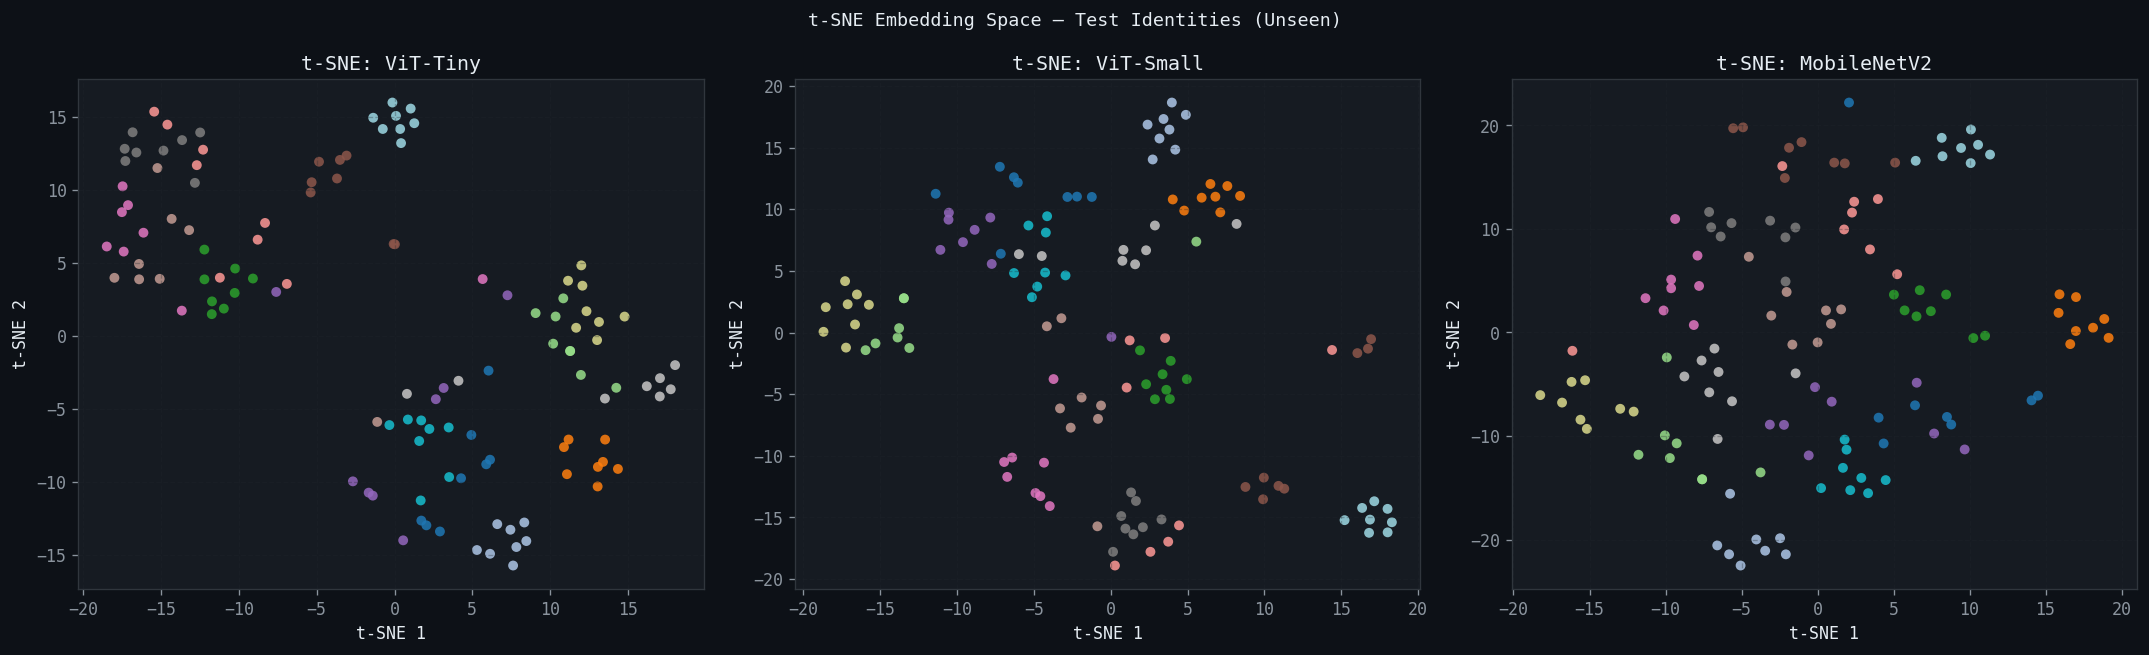

  fig4_tsne.png saved ✓
Generating Figure 6: Dashboard...
  ── Dashboard Komprehensif


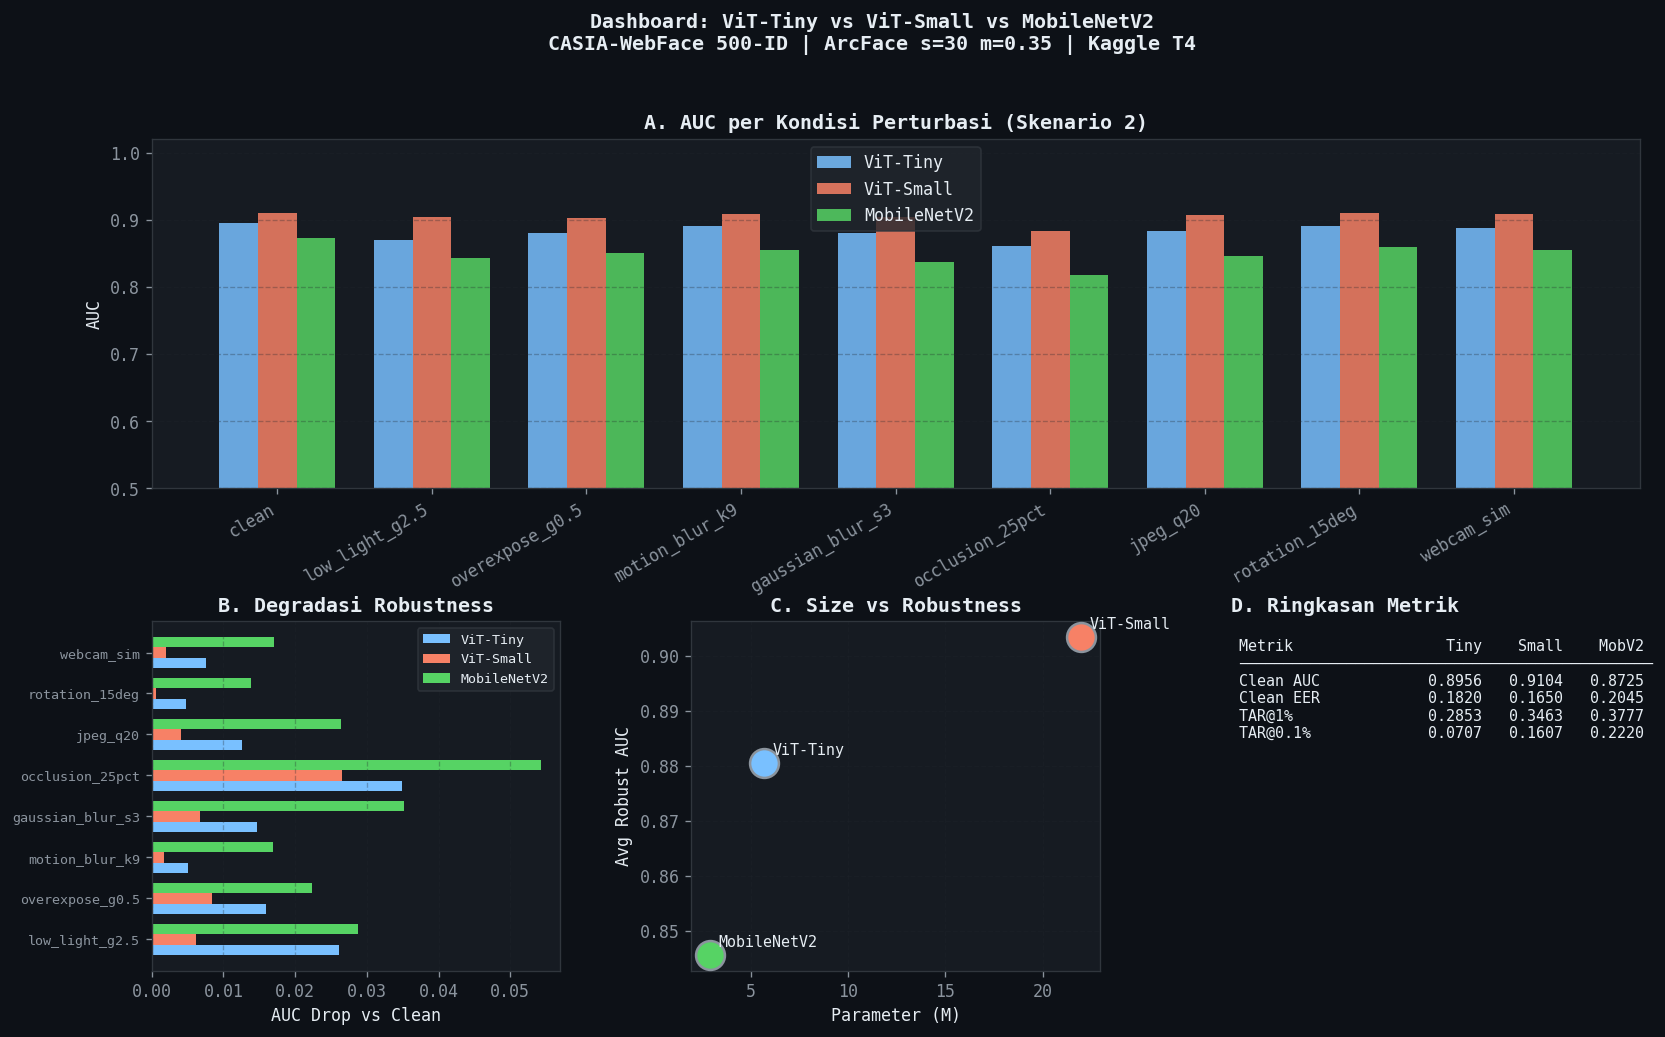

  fig6_dashboard.png saved ✓

BLOK 15 selesai ✓
Semua figure tersimpan di: /kaggle/working/outputs


21

In [19]:
# BLOK 15: Simpan Dashboard Final (Fig 4: t-SNE + Fig 6: Dashboard)
# Semua visualisasi per-blok sudah ditampilkan di BLOK 9-14.
# BLOK 15 hanya generate: t-SNE + Dashboard ringkasan komprehensif.

import gc
from sklearn.manifold import TSNE
plt.rcParams.update(PLT_STYLE)

CKPT_PATHS = {
    'ViT-Tiny'   : tiny_ckpt_path,
    'ViT-Small'  : small_ckpt_path,
    'MobileNetV2': mob_ckpt_path,
}
cond_names = list(PERTURBATIONS.keys())
cond_p     = [c for c in cond_names if c != 'clean']
PARAMS_M   = {'ViT-Tiny': 5.7, 'ViT-Small': 22.0, 'MobileNetV2': 2.9}

# ── Figure 4: t-SNE (load satu model per saat) ────────────────────────────
@torch.no_grad()
def get_embeddings_slim(ckpt_path, identities, max_ids=15, max_per_id=8):
    m, _ = load_best_model(ckpt_path)
    rng  = random.Random(CFG['SEED'])
    chosen = rng.sample(identities, min(max_ids, len(identities)))
    embs, lbls = [], []
    for idx, idd in enumerate(chosen):
        for p in sorted(idd.glob('*.jpg'))[:max_per_id]:
            img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
            t   = test_transform(img).unsqueeze(0).to(DEVICE)
            embs.append(m(t).cpu().numpy().flatten()); lbls.append(idx)
            del t
    del m; gc.collect(); torch.cuda.empty_cache()
    return np.array(embs, dtype=np.float32), np.array(lbls)

print('Generating Figure 4: t-SNE...')
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (mname, clr) in zip(axes, [
    ('ViT-Tiny',    CLR['tiny']),
    ('ViT-Small',   CLR['small']),
    ('MobileNetV2', CLR['mob']),
]):
    print(f'  t-SNE: {mname}...')
    embs, lbls = get_embeddings_slim(CKPT_PATHS[mname], test_ids)
    embs_2d = TSNE(
        n_components=2, random_state=CFG['SEED'],
        perplexity=15, init='pca',
        learning_rate='auto', n_iter=500,
    ).fit_transform(embs)
    ax.scatter(embs_2d[:,0], embs_2d[:,1], c=lbls, cmap='tab20',
               s=35, alpha=0.85, edgecolors='none')
    ax.set_title(f't-SNE: {mname}', color='#e6edf3')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.grid(alpha=0.3)
    del embs, embs_2d, lbls; gc.collect()

plt.suptitle('t-SNE Embedding Space — Test Identities (Unseen)',
             color='#e6edf3', fontsize=11)
plt.tight_layout()
save_show(fig, 'fig4_tsne.png', 't-SNE Embedding Space')

# ── Figure 6: Dashboard Komprehensif ──────────────────────────────────────
print('Generating Figure 6: Dashboard...')
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

RESULTS_VIZ = {
    'ViT-Tiny'   : (tiny_test,  tiny_history,  robust_tiny,  CLR['tiny']),
    'ViT-Small'  : (small_test, small_history, robust_small, CLR['small']),
    'MobileNetV2': (mob_test,   mob_history,   robust_mob,   CLR['mob']),
}

# Panel A: Grouped bar AUC per kondisi
ax_a = fig.add_subplot(gs[0, :])
x = np.arange(len(cond_names)); w = 0.25
for i, (mname, (_, _, robust, clr)) in enumerate(RESULTS_VIZ.items()):
    ax_a.bar(x + (i-1)*w,
             [robust[c]['auc'] for c in cond_names],
             w, color=clr, label=mname, alpha=0.85)
ax_a.set_xticks(x)
ax_a.set_xticklabels(cond_names, rotation=30, ha='right')
ax_a.set_ylabel('AUC'); ax_a.legend(); ax_a.grid(alpha=0.3, axis='y')
ax_a.set_ylim([0.5, 1.02])
ax_a.set_title('A. AUC per Kondisi Perturbasi (Skenario 2)',
               color='#e6edf3', fontweight='bold')

# Panel B: AUC Drop vs Clean
ax_b = fig.add_subplot(gs[1, 0])
x2 = np.arange(len(cond_p))
for i, (mname, (_, _, robust, clr)) in enumerate(RESULTS_VIZ.items()):
    drops = [robust['clean']['auc'] - robust[c]['auc'] for c in cond_p]
    ax_b.barh(x2 + (i-1)*0.25, drops, 0.25, color=clr, label=mname)
ax_b.set_yticks(x2)
ax_b.set_yticklabels(cond_p, fontsize=8)
ax_b.set_xlabel('AUC Drop vs Clean')
ax_b.set_title('B. Degradasi Robustness', color='#e6edf3', fontweight='bold')
ax_b.legend(fontsize=8); ax_b.grid(alpha=0.3, axis='x')

# Panel C: Params vs Avg Robust AUC
ax_c = fig.add_subplot(gs[1, 1])
for mname, (mtest, _, robust, clr) in RESULTS_VIZ.items():
    avg_r = np.mean([robust[c]['auc'] for c in cond_p])
    ax_c.scatter(PARAMS_M[mname], avg_r, s=300, color=clr,
                 edgecolor='#8b949e', lw=1.5, label=mname, zorder=3)
    ax_c.annotate(mname, (PARAMS_M[mname], avg_r),
                  xytext=(5, 5), textcoords='offset points', fontsize=9)
ax_c.set_xlabel('Parameter (M)')
ax_c.set_ylabel('Avg Robust AUC')
ax_c.set_title('C. Size vs Robustness', color='#e6edf3', fontweight='bold')
ax_c.grid(alpha=0.3)

# Panel D: Summary table
ax_d = fig.add_subplot(gs[1, 2])
ax_d.axis('off')
rows = [
    f'{"Metrik":<18} {"Tiny":>8} {"Small":>8} {"MobV2":>8}',
    '─' * 46,
]
for key, lbl in [
    ('auc',           'Clean AUC'),
    ('eer',           'Clean EER'),
    ('tar_far_1pct',  'TAR@1%'),
    ('tar_far_01pct', 'TAR@0.1%'),
]:
    rows.append(
        f'{lbl:<18} {tiny_test[key]:>8.4f} '
        f'{small_test[key]:>8.4f} {mob_test[key]:>8.4f}'
    )

# FIX 1: '\n'.join(rows) — bukan ''.join atau string terputus
ax_d.text(
    0.02, 0.95,
    '\n'.join(rows),          # ← FIX 1: string join yang benar
    family='monospace',
    fontsize=9,
    va='top',
    color='#e6edf3',
    transform=ax_d.transAxes,
)
ax_d.set_title('D. Ringkasan Metrik', color='#e6edf3',
               fontweight='bold', loc='left')

# FIX 2: suptitle — gunakan \n bukan newline literal di dalam f-string
fig.suptitle(
    f'Dashboard: ViT-Tiny vs ViT-Small vs MobileNetV2\n'        # ← FIX 2
    f'CASIA-WebFace 500-ID | ArcFace s={CFG["ARCFACE_SCALE"]} '
    f'm={CFG["ARCFACE_MARGIN"]} | Kaggle T4',
    color='#e6edf3',
    fontweight='bold',
    fontsize=12,
    y=0.998,
)
save_show(fig, 'fig6_dashboard.png', 'Dashboard Komprehensif')

print('\nBLOK 15 selesai ✓')
print('Semua figure tersimpan di:', CFG['OUTPUT_DIR'])
gc.collect()

## BLOK 16 — Export ONNX & Validasi Numerik (Edge-Readiness)

Output blok ini adalah artifact yang dibawa ke **fase deployment Jetson Nano 4GB** (Skenario 4–5):
- File `.onnx` per backbone (opset 13, kompatibel TensorRT 8.x)
- File `calibration.json` per backbone: threshold EER, TAR@FAR, metadata model

Validasi numerik PyTorch ↔ ONNX dilakukan dengan toleransi max_diff < 1e-4.  
Ini memastikan tidak ada drift presisi saat model dieksekusi di platform berbeda.

In [20]:
# INSTALL ONNX dependencies — jalankan sebelum BLOK 16
import subprocess, sys

pkgs = [
    'onnx',
    'onnxruntime',
    'onnxscript',      # Dependency baru PyTorch >= 2.0 untuk ONNX export
]

for pkg in pkgs:
    print(f'  Installing {pkg}...')
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f'  {pkg} OK ✓')
    else:
        print(f'  {pkg} GAGAL: {result.stderr[:200]}')

# Verifikasi
import onnx, onnxruntime, onnxscript
print(f'\n  onnx       : {onnx.__version__}')
print(f'  onnxruntime: {onnxruntime.__version__}')
print(f'  onnxscript : {onnxscript.__version__}')
print('  Semua dependency OK — siap jalankan BLOK 16')

  Installing onnx...
  onnx OK ✓
  Installing onnxruntime...
  onnxruntime OK ✓
  Installing onnxscript...
  onnxscript OK ✓

  onnx       : 1.21.0
  onnxruntime: 1.26.0
  onnxscript : 0.7.0
  Semua dependency OK — siap jalankan BLOK 16


In [21]:
# BLOK 16: Export ONNX — Fix opset + fix weights tidak tersimpan
# FIX 1: Ganti opset 13 → 18 (kompatibel PyTorch >= 2.1)
# FIX 2: Tambah dynamo=False agar weights ikut tersimpan di file
# FIX 3: Verifikasi ukuran file masuk akal sebelum lanjut

import onnx, onnxruntime as ort
import json, gc
import numpy as np

# Cek versi ONNX opset yang didukung PyTorch ini
import torch.onnx
_supported = torch.onnx.producer_version
print(f'  PyTorch ONNX producer: {_supported}')
print(f'  Menggunakan opset_version=18 (kompatibel PyTorch >= 2.1)')

# Expected file sizes (MB) untuk validasi
EXPECTED_SIZE_MB = {
    'vit_tiny'    : (15, 35),   # 5.7M params × 4 bytes ≈ 22MB
    'vit_small'   : (70, 100),  # 22M params × 4 bytes ≈ 88MB
    'mobilenet_v2': (8,  20),   # 2.9M params × 4 bytes ≈ 12MB
}

def export_and_validate(ckpt_path, name, test_res, cfg):
    print(f'\n  [{name}] Loading checkpoint...')
    model, ckpt = load_best_model(ckpt_path)
    core = get_core(model)
    core.eval()
    core = core.cpu()

    onnx_path = cfg['OUTPUT_DIR'] / f'{name}.onnx'
    dummy     = torch.zeros(1, 3, cfg['IMG_SIZE'], cfg['IMG_SIZE'])

    print(f'  [{name}] Exporting ONNX opset 18...')
    try:
        torch.onnx.export(
            core,
            dummy,
            str(onnx_path),
            opset_version      = 18,       # FIX 1: opset 18
            input_names        = ['input'],
            output_names       = ['embedding'],
            dynamic_axes       = {
                'input'    : {0: 'batch'},
                'embedding': {0: 'batch'},
            },
            do_constant_folding = True,
            dynamo             = False,     # FIX 2: legacy API → weights ikut tersimpan
        )
    except TypeError:
        # Fallback jika parameter 'dynamo' tidak dikenal versi ini
        torch.onnx.export(
            core, dummy, str(onnx_path),
            opset_version      = 18,
            input_names        = ['input'],
            output_names       = ['embedding'],
            dynamic_axes       = {'input': {0:'batch'}, 'embedding': {0:'batch'}},
            do_constant_folding = True,
        )

    # FIX 3: Verifikasi ukuran file masuk akal
    size_mb = onnx_path.stat().st_size / 1e6
    lo, hi  = EXPECTED_SIZE_MB.get(name, (1, 999))
    if size_mb < lo:
        print(f'  [{name}] ⚠ WARNING: File hanya {size_mb:.1f}MB!')
        print(f'  [{name}]   Ekspektasi {lo}-{hi}MB — weights mungkin tidak tersimpan')
        size_status = 'WARN'
    else:
        print(f'  [{name}] File size: {size_mb:.1f}MB ✓')
        size_status = 'OK'

    # Validasi struktur ONNX
    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)
    del onnx_model

    # Validasi numerik PyTorch vs ONNX Runtime
    print(f'  [{name}] Validasi numerik...')
    sess = ort.InferenceSession(
        str(onnx_path),
        providers=['CPUExecutionProvider']
    )
    with torch.no_grad():
        pt_out  = core(dummy).numpy()
    ort_out = sess.run(['embedding'], {'input': dummy.numpy()})[0]
    max_diff = float(np.abs(pt_out - ort_out).max())
    num_status = 'PASS' if max_diff < 1e-4 else 'FAIL'
    print(f'  [{name}] max_diff={max_diff:.2e} [{num_status}]')

    # Overall status
    status = 'PASS' if (num_status == 'PASS' and size_status == 'OK') else 'WARN'

    # Simpan calibration.json
    calib = {
        'model_name'      : name,
        'backbone_key'    : ckpt.get('backbone_key', name),
        'img_size'        : cfg['IMG_SIZE'],
        'embedding_dim'   : cfg['EMBEDDING_DIM'],
        'arcface_scale'   : cfg['ARCFACE_SCALE'],
        'arcface_margin'  : cfg['ARCFACE_MARGIN'],
        'onnx_opset'      : 18,
        'threshold_val'   : float(ckpt['val_threshold']),
        'threshold_test'  : float(test_res['threshold']),
        'val_auc'         : float(ckpt['val_auc']),
        'val_eer'         : float(ckpt['val_eer']),
        'test_auc'        : float(test_res['auc']),
        'test_eer'        : float(test_res['eer']),
        'test_accuracy'   : float(test_res['accuracy']),
        'tar_far_1pct'    : float(test_res['tar_far_1pct']),
        'tar_far_01pct'   : float(test_res['tar_far_01pct']),
        'onnx_size_mb'    : round(size_mb, 2),
        'onnx_max_diff'   : max_diff,
        'onnx_num_status' : num_status,
        'onnx_size_status': size_status,
        'imagenet_mean'   : [0.485, 0.456, 0.406],
        'imagenet_std'    : [0.229, 0.224, 0.225],
        'deployment_notes': {
            'target_device'    : 'Jetson Nano 4GB',
            'tensorrt_opset'   : 18,
            'precision_targets': ['FP32', 'FP16', 'INT8'],
            'note'             : 'opset 18 kompatibel TensorRT 8.5+'
        }
    }
    json_path = cfg['OUTPUT_DIR'] / f'{name}_calibration.json'
    with open(json_path, 'w') as jf:
        json.dump(calib, jf, indent=2)
    print(f'  [{name}] calibration.json saved ✓')

    del model, core, sess, pt_out, ort_out, dummy
    gc.collect(); torch.cuda.empty_cache()
    return onnx_path, json_path, status


print("=" * 70)
print("  BLOK 16 — Export ONNX & Validasi Numerik")
print("  opset=18 | dynamo=False | weights embedded")
print("=" * 70)

export_configs = [
    (tiny_ckpt_path,  'vit_tiny',     tiny_test),
    (small_ckpt_path, 'vit_small',    small_test),
    (mob_ckpt_path,   'mobilenet_v2', mob_test),
]

results_16 = {}
for ckpt_p, name, test_res in export_configs:
    _, _, status = export_and_validate(ckpt_p, name, test_res, CFG)
    results_16[name] = status

# Ringkasan
print(f'\n{"=" * 70}')
print(f'  Ringkasan Export ONNX')
print(f'  {"Model":<16} {"Status":>8} {"Size":>10} {"Validasi"}')
print(f'  {"-" * 60}')
for name in results_16:
    p = CFG['OUTPUT_DIR'] / f'{name}.onnx'
    mb = f'{p.stat().st_size/1e6:.1f}MB' if p.exists() else 'N/A'
    lo, hi = EXPECTED_SIZE_MB.get(name, (1,999))
    size_ok = '✓' if p.exists() and p.stat().st_size/1e6 >= lo else '⚠'
    print(f'  {name:<16} {results_16[name]:>8}   {mb:>8} {size_ok}')

print(f'\n  BLOK 16 selesai ✓')
print(f'\n{"=" * 70}')
print('  Catatan Fase 2 (Jetson Nano, Skenario 4-5):')
print('  1. Convert .onnx → TensorRT .engine (TRT 8.x, opset 13)')
print('  2. INT8 calibration dengan 1200 gambar')
print('  3. Kalibrasi threshold per sensor (IMX219 vs C270) — Bab 3.7 Langkah 4')
print('  4. Ukur latensi median/p95, throughput FPS, RAM peak')

  PyTorch ONNX producer: 2.10.0
  Menggunakan opset_version=18 (kompatibel PyTorch >= 2.1)
  BLOK 16 — Export ONNX & Validasi Numerik
  opset=18 | dynamo=False | weights embedded

  [vit_tiny] Loading checkpoint...
  [vit_tiny] Exporting ONNX opset 18...
  [vit_tiny] File size: 22.7MB ✓
  [vit_tiny] Validasi numerik...
  [vit_tiny] max_diff=1.90e-07 [PASS]
  [vit_tiny] calibration.json saved ✓

  [vit_small] Loading checkpoint...
  [vit_small] Exporting ONNX opset 18...
  [vit_small] File size: 87.6MB ✓
  [vit_small] Validasi numerik...
  [vit_small] max_diff=1.86e-07 [PASS]
  [vit_small] calibration.json saved ✓

  [mobilenet_v2] Loading checkpoint...
  [mobilenet_v2] Exporting ONNX opset 18...
  [mobilenet_v2] File size: 11.5MB ✓
  [mobilenet_v2] Validasi numerik...
  [mobilenet_v2] max_diff=1.86e-07 [PASS]
  [mobilenet_v2] calibration.json saved ✓

  Ringkasan Export ONNX
  Model              Status       Size Validasi
  ------------------------------------------------------------
 

## BLOK 17-Package Output → ZIP & Download

In [22]:
# # BLOK 17: Package Output → ZIP & Download
# # Mengemas semua hasil eksperimen ke dalam file ZIP untuk didownload
# # Output: checkpoint .pth, ONNX .onnx, calibration .json, figures .png

# import zipfile, os, shutil
# from pathlib import Path
# from IPython.display import FileLink, display
# import gc

# print("=" * 60)
# print("  BLOK 17 — Package Output & Download")
# print("=" * 60)

# OUTPUT_DIR  = CFG['OUTPUT_DIR']           # /kaggle/working/outputs
# WORKING_DIR = Path('/kaggle/working')
# ZIP_PATH    = WORKING_DIR / 'thesis_vit_results.zip'

# # Hapus zip lama jika ada
# if ZIP_PATH.exists():
#     ZIP_PATH.unlink()
#     print("  ZIP lama dihapus")

# # ── Kumpulkan semua file yang akan di-zip ────────────────────────────────
# file_groups = {
#     'checkpoints' : list(OUTPUT_DIR.glob('*.pth')),
#     'onnx'        : list(OUTPUT_DIR.glob('*.onnx')),
#     'calibration' : list(OUTPUT_DIR.glob('*.json')),
#     'figures'     : list(OUTPUT_DIR.glob('*.png')),
#     'pairs'       : list(OUTPUT_DIR.glob('*pairs*.json')),
# }

# print(f"\n  File yang akan di-zip:")
# total_size = 0
# for group, files in file_groups.items():
#     if files:
#         group_size = sum(f.stat().st_size for f in files) / 1e6
#         total_size += group_size
#         print(f"  {group:<14}: {len(files):2d} file | {group_size:.1f} MB")
#         for f in sorted(files):
#             print(f"    {f.name}")
# print(f"\n  Total estimasi: {total_size:.1f} MB")

# # ── Buat ZIP ─────────────────────────────────────────────────────────────
# print(f"\n  Membuat ZIP...")
# written = 0
# with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
#     for group, files in file_groups.items():
#         for f in sorted(files):
#             # Simpan dengan struktur folder di dalam ZIP
#             arcname = f'{group}/{f.name}'
#             zf.write(f, arcname=arcname)
#             written += 1

# zip_size = ZIP_PATH.stat().st_size / 1e6
# print(f"  {written} file dikemas → {ZIP_PATH.name} ({zip_size:.1f} MB) ✓")

# # ── Tampilkan link download ───────────────────────────────────────────────
# print(f"\n  Link Download:")
# print(f"  {'─' * 50}")
# display(FileLink(str(ZIP_PATH), result_html_prefix='  📦 Download: '))
# print(f"  {'─' * 50}")

# # ── Ringkasan isi ZIP ─────────────────────────────────────────────────────
# print(f"\n  Isi ZIP (struktur folder):")
# with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
#     for info in sorted(zf.infolist(), key=lambda x: x.filename):
#         size_kb = info.file_size / 1024
#         print(f"    {info.filename:<45} {size_kb:8.1f} KB")

# print(f"\n  BLOK 17 selesai ✓")
# print(f"  Klik link di atas untuk download, atau ambil dari:")
# print(f"  Output panel → /kaggle/working/thesis_vit_results.zip")
# gc.collect()